(mmm_control_dimensionality)=
# Control Dimensionality and ROAS

How many control variables should an MMM include, and what does the answer cost you?

The instinct is that controls are cheap. They are not the treatment, they are not what you report, and leaving one out risks omitted-variable bias — so the temptation is to throw in everything: holidays, weather, competitor pricing, macro indices, one dummy per promotion. There is a well-founded theoretical worry that this quietly damages the number you actually care about, **total media ROAS**, through the prior alone. This notebook builds the experiment that tests it, and reports both halves of the answer.

The problem is not confounding. We deliberately generate controls that are *independent of media spend*, so they cannot bias ROAS through a back-door path — in the vocabulary of [Cinelli, Forney and Pearl (2024)](https://doi.org/10.1177/00491241221099552) they are **neutral controls**. Anything we observe is therefore attributable to prior geometry alone.

## What goes wrong in the prior

PyMC-Marketing gives each control coefficient an independent Normal prior whose scale does not depend on how many controls there are. Add controls and the *total* variance the model expects the control block to explain grows linearly in $K$, while the prior on the residual scale stays put. The implied prior on $R^2$ therefore marches towards 1. We will see it reach 0.999 at $K = 2$ under the library default, with the share of prior variance left for media collapsing to 0.000 — a prior that has decided, before seeing any data, that the model explains everything and media explains none of it.

The dimension-aware alternative budgets a *fixed* amount of explained variance and splits it across however many controls happen to be present. That is the **R2D2** prior of [Zhang, Naughton, Bondell and Reich (2022)](https://doi.org/10.1080/01621459.2020.1825449): put a prior on $R^2$, convert it into a total coefficient-variance budget, and divide that budget over the coefficients with a Dirichlet. Its implied prior $R^2$ is flat in $K$, by construction.

## What that costs in the posterior

At $K = 25$ controls against $n = 156$ weeks — an entirely ordinary MMM — the reported number moves. Total ROAS comes out at 2.33 under the library default and 2.35 under a hand-tightened Normal, against 2.10 under R2D2 and a true 2.02. In absolute error that is 0.36 and 0.38 against 0.11: a factor of three.

The comparison that isolates *why* is the one between the two Normal arms. They differ by a factor of 20 in coefficient scale and they give the same answer to two decimal places. So this is not a story about picking a better `sigma`; a modeller who tightens the default by hand buys nothing. What separates R2D2 is that its budget knows how many controls it is being divided among.

The trajectory across $K$ is worth stating in full, because it contains the uncomfortable part:

| | $K=0$ | $K=10$ | $K=20$ | $K=25$ |
| --- | --- | --- | --- | --- |
| Normal, default | −0.33 | +0.04 | +0.33 | +0.36 |
| Normal, tightened | −0.33 | +0.04 | +0.33 | +0.38 |
| Split R2D2 | −0.33 | −0.03 | +0.10 | +0.11 |

Bias in total ROAS, truth 2.02. With no controls the model *under*-attributes to media, because the seasonal signal it cannot see inflates the residual. The first ten controls fix that under every prior. Past ten, the two Normal fits sail through the truth and keep going, while R2D2 stays put. And note where the default Normal ends up at $K = 25$: an absolute error of 0.36, no better than the 0.33 of the model with **no controls at all**. That is Table 4 of the source paper — the full model is not an improvement on the base model — reproduced here. R2D2 at the same $K$ is three times better than the base model.

The mechanism is not where you would look for it. All three priors agree on how much media *varies* (23.6–23.9% of target variance, against a true 18.9%). They disagree on how much media *is*: media's share of mean sales comes out at 17.9% and 18.0% under the Normal priors, against 16.0% under R2D2 and a true 15.2%, with the intercept taking the other side of the trade. ROAS is a level, not a variance, which is why a diagnostic built on variance shares would show almost nothing while the reported number moves by 17%.

Two things this notebook cannot tell you. Every 90% interval covers the truth, in all 16 fits, so the priors are separated by point accuracy and interval width and not by coverage. And this is one dataset: the ordering is consistent across $K$ and reproduced under a second choice of media priors, but a single realisation cannot establish the size of the effect. The repetition machinery is at the end, defaulting to one replication to keep the notebook fast.

## Relationship to the source paper

This notebook is a media-mix translation of Experiment 4 of [*To select or not to select*](https://arxiv.org/abs/2606.22850) (Section 5.4). The paper studies a randomised experiment with a treatment $z$, a treatment effect $\alpha$, and $p$ neutral covariates, and asks how the posterior for $\alpha$ evolves as $p$ grows under different priors. The mapping:

| Paper | This notebook |
| --- | --- |
| treatment $z$ | media spend, passed through adstock and saturation |
| treatment effect $\alpha$ | **total media ROAS** |
| covariates $X$, drawn iid, independent of $z$ | control variables, persistent but independent of spend |
| $M_{\text{base}}$ (treatment only) | an MMM with `control_columns=None` |
| $M_{\text{full}}$ at $p \in \{10, 50, 100\}$ | an MMM fit on the first $K$ controls, $K \in \{2, 5, 10, 20, 25\}$ |
| $n_{\text{obs}} = 150$ | $n = 156$ weeks (three years of weekly data) |

Two details of the mapping are worth flagging up front. First, the base model is the *punchline*, not a footnote: Table 4 of the paper reports that the Normal full model is **worse** than the base model (RMSE 0.30 vs 0.27, coverage 0.87 vs 0.92), so "add the controls, they cannot hurt" is exactly the belief under test. Second, of the paper's three prior specifications we implement **Normal** and **split** (R2D2 on the controls, media priors untouched). The joint R2D2, which shrinks the media coefficients too and which the paper shows to be badly biased, is out of scope.

Two deliberate departures. First, we stay well *inside* the paper's dimension range rather than pushing past it. The paper runs up to $p/n \approx 0.67$; our largest fit is $K = 25$ against $n = 156$, so $K/n \approx 0.16$. That is the boring, everyday MMM — three years of weekly data and a couple of dozen candidate controls — and it is the more useful test, because it is easy to make any prior look bad at $p \approx n$ where the model is barely identified and the sampler is in trouble anyway. The question a practitioner needs answered is whether the control prior is already doing damage at dimensions that look entirely reasonable, and the answer here is yes.

Second, our controls are **persistent** rather than iid. Real candidate controls are smooth series — prices, weather indices, macro aggregates — and smoothness is what lets a control block partially reproduce a smooth media signal in a finite sample even when the two are independent in the population. With iid columns there is very little for the prior to arbitrate; with $\phi = 0.85$ there is, and the diagnostics below measure how much.

## Prepare Notebook

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import pytensor.tensor as pt
import seaborn as sns
import xarray as xr
from pymc_extras.prior import Prior
from pytensor.xtensor.type import as_xtensor

from pymc_marketing.constants import DAYS_IN_YEAR
from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.mmm import MMM
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation
from pymc_marketing.special_priors import SpecialPrior

warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

The experiment is driven by a handful of constants. `N_DATES` and `K_MAX` set the shape of the problem; `K_GRID` is the sequence of nested control subsets we fit.

In [2]:
SEED = 42

N_DATES = 156  # three years of weekly data
N_CHANNELS = 5
L_MAX = 8  # adstock window, in weeks
K_MAX = 25  # size of the pool of candidate controls
CHOL_ETA = 10.0  # LKJ concentration for the spend correlation matrix
CONTROL_PHI = 0.85  # weekly persistence of the control series

K_GRID = [0, 2, 5, 10, 20, 25]

CHANNELS = [f"x{i + 1}" for i in range(N_CHANNELS)]
CONTROLS = [f"c{k + 1}" for k in range(K_MAX)]
DATES = pd.date_range("2021-01-04", freq="W-MON", periods=N_DATES)

## The data-generating process

We need a dataset where the true total ROAS is known exactly and identical for every $K$, so that any movement in the posterior is attributable to the control prior and nothing else. We build it in three pieces: spend, controls, and the target.

### Media spend

Channel spend comes from an LKJ-Cholesky generative model, the same construction used in the parameter recovery notebook, {ref}`mmm_data_generator`. It gives realistically correlated channel spend with per-channel trends, and `softplus` enforces non-negativity.

One deviation from that notebook: the per-channel scale prior is `Gamma(6, 2)` rather than `Exponential(1/3)`. Both have mean 3, but the Exponential regularly draws values near zero, which produces a channel whose spend barely moves across the three years. Because the MMM divides each channel by its own maximum before saturating, such a channel sits permanently at the flat top of its saturation curve and contributes an almost constant term — one that is not separable from the intercept. The Gamma keeps every channel's spend on a usable dynamic range.

In [3]:
def draw_spend(rng: np.random.Generator) -> np.ndarray:
    """Draw one realisation of correlated, trending, non-negative channel spend."""
    coords = {"channel": CHANNELS, "date": np.arange(N_DATES)}
    t = np.arange(N_DATES) / N_DATES

    with pm.Model(coords=coords) as spend_model:
        t_data = pm.Data("t", t, dims=("date",))
        L, _, _ = pm.LKJCholeskyCov(
            "L",
            n=N_CHANNELS,
            eta=CHOL_ETA,
            sd_dist=pm.Gamma.dist(alpha=6, beta=2),
        )
        a = pm.Normal("a", mu=0, sigma=1, dims="channel")
        b = pm.Normal("b", mu=0, sigma=1, dims="channel")
        mu = pm.Deterministic("mu", a + b * t_data[..., None], dims=("date", "channel"))
        x_raw = pm.MvNormal("x_raw", mu=mu, chol=L, dims=("date", "channel"))
        pm.Deterministic("x", pt.softplus(x_raw), dims=("date", "channel"))

    return pm.draw(spend_model.x, draws=1, random_seed=rng)

### The true media contribution

We call `geometric_adstock` and `logistic_saturation` from `pymc_marketing.mmm.transformers` directly, at fixed true `alpha` and `lam`, so the truth matches the model's functional form *exactly* rather than approximately. Two settings have to line up with what the `MMM` class does internally, or the truth will silently disagree with the model:

- the transformations are applied to **max-scaled** spend, `x / x.max()`, because `MMM` max-scales each channel before the forward pass;
- `normalize=True`, because that is the default on the `GeometricAdstock` wrapper even though the underlying `geometric_adstock` function defaults to `False`.

`beta` enters `LogisticSaturation` as a pure multiplicative scale, so evaluating the shape once at `beta = 1` lets us solve the variance budget below in closed form. This is why we call the transformers directly instead of routing the target through `pm.do` and `sample_prior_predictive`, which would need a two-pass loop to hit a variance target.

In [4]:
def media_shape(
    spend_scaled: np.ndarray, alpha: np.ndarray, lam: np.ndarray
) -> np.ndarray:
    """Adstock then saturation at unit beta, matching the MMM's forward pass."""
    adstocked = geometric_adstock(
        as_xtensor(spend_scaled, dims=("date", "channel")),
        alpha=as_xtensor(alpha, dims=("channel",)),
        l_max=L_MAX,
        dim="date",
        normalize=True,
    )
    saturated = logistic_saturation(adstocked, lam=as_xtensor(lam, dims=("channel",)))
    return saturated.transpose("date", "channel").values.eval()

### Controls, variance budget, and the target

The controls are $K_{\max}$ columns, standardised and independent of spend. Standardising matters here because, unlike the target and the channels, `MMM` does **not** scale controls — so `gamma_control` lives in scaled-target-per-raw-control units, and standardised controls are what keep that interpretable. It is not a formality either: before rescaling, the sine column has standard deviation $1/\sqrt{2}$ and the persistent columns range from 0.69 to 1.28, so without it the decaying-importance ladder below would be scrambled by scale noise and a shared variance budget would be comparing unlike things.

The **first** control is a yearly sine wave, and since importance decays down the block it is also the control with the largest true coefficient. This is cosmetic in one sense — it gives the target the seasonal shape that makes it recognisable as sales data instead of noise around a trend — but it has two real consequences. It makes the $K = 0$ model genuinely *misspecified* rather than merely incomplete, since nothing else in the model can absorb a yearly cycle (`yearly_seasonality` is off in every fit, deliberately: we want the controls to be the only route to that signal). And it means the first step up the $K$ grid buys a great deal.

The remaining columns are **AR(1) with $\phi = 0.85$**, not white noise, with the innovation scale chosen to keep the stationary variance at 1. This is the departure that makes the experiment interesting, and it does two things at once. Persistent columns are mutually correlated in a finite sample — with $\phi = 0.85$ the effective sample size per column is around 12, not 156 — so the control block is internally collinear rather than an orthogonal basis, and the likelihood no longer pins each coefficient down on its own. And a block of smooth columns can partially reproduce a smooth media signal, which an iid block largely cannot. Both are measured in the cell after next.

```{warning}
**Spend does not depend on the season here.** Real marketers spend into high season, which makes seasonality a genuine *confounder* of media and one of the main reasons to include it. Our spend is generated without reference to any control, so every control in this notebook — the seasonal one included — remains **neutral** in the Cinelli–Forney–Pearl sense. That is what isolates the prior-geometry effect we want to measure, but it also means nothing here speaks to the confounding case. If your spend follows the season, you are in a different problem and omitting the seasonal control biases ROAS for reasons that have nothing to do with this notebook.
```

The true coefficients **decay** down the block, $\gamma_k \propto (1 - k/K_{\max})^2$. This is a deliberate departure from the paper, which gives every covariate the same coefficient (`beta <- array(0.1, c(p, 1))`). The decaying version is the situation an analyst is actually in: you order candidate controls by how much you believe in them, the first few genuinely matter, and the tail is close to noise. The square makes that ordering steep enough to bite — the last control's coefficient is not merely smaller than the first's, it is negligible — so each step up the $K$ grid buys less signal than the last, while under a Normal prior it costs just as much variance budget as the first.

The rest of the DGP is a variance budget with three knobs:

- **`media_contribution_share`** — the fraction of total sales driven by media. Since $\mathbb{E}[y] = \text{baseline} + \mathbb{E}[\text{media}]$ and the controls and noise are mean-zero, targeting a share $s$ means $\mathbb{E}[\text{media}] = s \cdot \text{baseline} / (1 - s)$, which fixes the overall scale of `saturation_beta`. Default 0.15.
- **`delta_media`** — media's share of *explained* variance, the analogue of equation (34) in the paper. The media level above already fixes media's variance, so this knob sets the control block's variance. Default 0.25: the controls do most of the explaining, as they usually do in a real MMM.
- **`true_r2`** — the fraction of the target's variance that media and controls jointly explain, which pins the residual scale (the paper's footnote 15). Default 0.75. Together with `delta_media` this fixes the quantity the R2D2 prior is actually a prior on — the control block's variance against the residual, media excluded from both — at $0.75 / (0.75 + 1/3) = 0.692$. A less noisy target would push that above 0.9, which is far enough into the corner of the unit interval that no honest Beta prior can be centred near it.

Finally we divide the target by its own maximum. This is not cosmetic: `MMM` max-scales the target, so normalising here makes the model's internal scale exactly 1 and lets us report every true parameter in the units the model actually works in.

In [5]:
def simulate(
    seed: int,
    *,
    media_contribution_share: float = 0.15,
    true_r2: float = 0.75,
    delta_media: float = 0.25,
    baseline: float = 1.0,
    spend_to_revenue: float = 0.075,
) -> tuple[pd.DataFrame, dict]:
    """Generate one dataset together with its exact ground truth."""
    rng = np.random.default_rng(seed)

    spend_raw = draw_spend(rng)
    spend_scaled = spend_raw / spend_raw.max(axis=0)

    alpha_true = rng.beta(1, 3, size=N_CHANNELS)
    lam_true = rng.gamma(shape=3, scale=1, size=N_CHANNELS)
    shape = media_shape(spend_scaled, alpha_true, lam_true)

    # Relative betas that equalise each channel's mean contribution, so that no
    # single channel dominates the media term.
    beta_rel = 1.0 / shape.mean(axis=0)
    shape_unit = shape @ beta_rel

    controls = np.empty((N_DATES, K_MAX))
    # The leading control is a yearly wave rather than noise. Because importance
    # decays down the block, it carries the largest true coefficient, so the
    # target inherits the seasonal shape an MMM practitioner expects to see.
    # Spend is drawn independently of it, so it stays a neutral control.
    controls[:, 0] = np.sin(2 * np.pi * DATES.dayofyear.to_numpy() / DAYS_IN_YEAR)
    # The rest are AR(1), not white noise: real candidate controls are persistent
    # series, and persistence is what lets a control block partially reproduce a
    # smooth media signal in a finite sample.  The innovation scale keeps the
    # stationary variance at 1.
    controls[0, 1:] = rng.normal(size=K_MAX - 1)
    innovations = rng.normal(
        scale=np.sqrt(1 - CONTROL_PHI**2), size=(N_DATES, K_MAX - 1)
    )
    for t in range(1, N_DATES):
        controls[t, 1:] = CONTROL_PHI * controls[t - 1, 1:] + innovations[t]
    controls = (controls - controls.mean(axis=0)) / controls.std(axis=0)

    media_mean = media_contribution_share * baseline / (1 - media_contribution_share)
    beta_true = beta_rel * media_mean / shape_unit.mean()
    media = shape @ beta_true

    var_media = media.var()
    var_control = var_media * (1 - delta_media) / delta_media
    var_explained = var_media + var_control

    # Importance decays linearly down the control block, so the leading columns
    # carry real signal and the trailing ones are all but noise.
    importance = (1.0 - np.arange(K_MAX) / K_MAX) ** 2
    control_signal = controls @ importance
    gamma_true = importance * np.sqrt(var_control / control_signal.var())
    control = controls @ gamma_true

    sigma_true = np.sqrt(var_explained * (1 - true_r2) / true_r2)
    noise = rng.normal(scale=sigma_true, size=N_DATES)

    y_raw = baseline + media + control + noise
    scale = y_raw.max()
    y = y_raw / scale

    spend_level = spend_to_revenue * y.sum() / spend_raw.sum()
    spend = spend_raw * spend_level

    truth = {
        # True parameters, expressed in the model's internal (scaled-target) units.
        "intercept": baseline / scale,
        "adstock_alpha": alpha_true,
        "saturation_lam": lam_true,
        "saturation_beta": beta_true / scale,
        "gamma_control": gamma_true / scale,
        "y_sigma": sigma_true / scale,
        # Realised summaries of this particular dataset.
        "media_contribution": media / scale,
        "total_roas": (media / scale).sum() / spend.sum(),
        "media_contribution_share": media.sum() / y_raw.sum(),
        "delta_media": var_media / var_explained,
        "r2": (media + control).var() / y_raw.var(),
        # The quantity the R2D2 prior is actually a prior on: the control block
        # against the residual, with media excluded from both terms.
        "control_r2": control.var() / (control.var() + sigma_true**2),
        "target_scale": scale,
    }

    frame = {"date": DATES}
    frame |= {channel: spend[:, i] for i, channel in enumerate(CHANNELS)}
    frame |= {control_name: controls[:, k] for k, control_name in enumerate(CONTROLS)}
    frame["y"] = y

    return pd.DataFrame(frame), truth

We draw the dataset **once** and hold it fixed for every model below. `y` is therefore byte-identical across all fits, and the nested subsets $K \in$ `K_GRID` all come from the same pool of `K_MAX` columns.

In [6]:
data, truth = simulate(SEED)

pd.Series(
    {
        "true total ROAS": truth["total_roas"],
        "media share of sales": truth["media_contribution_share"],
        "intercept share of sales": truth["intercept"] / data["y"].mean(),
        "media share of explained variance": truth["delta_media"],
        "true R-squared": truth["r2"],
        "true control R-squared (against residual)": truth["control_r2"],
        "true residual sigma (scaled target)": truth["y_sigma"],
        "true gamma, first control (scaled target)": truth["gamma_control"][0],
        "true gamma, last control (scaled target)": truth["gamma_control"][-1],
        "target scale": truth["target_scale"],
    }
).round(4)

true total ROAS                              2.0221
media share of sales                         0.1517
intercept share of sales                     0.8594
media share of explained variance            0.2500
true R-squared                               0.7557
true control R-squared (against residual)    0.6923
true residual sigma (scaled target)          0.0572
true gamma, first control (scaled target)    0.0380
true gamma, last control (scaled target)     0.0001
target scale                                 1.6318
dtype: float64

Ground-truth total ROAS is the total true media contribution divided by total spend — a single number, identical for every $K$ because the data never change.

The controls are independent of spend by construction, but with $n = 156$ the *sample* correlations are not exactly zero, and it is finite-sample overlap rather than population dependence that lets a neutral control move ROAS. Three measurements, in increasing order of how much they matter.

**Correlation with spend.** The direct route: a control that happens to track a channel competes with it for attribution. These stay small.

**Correlation within the block.** The persistent columns are mutually correlated even though they are independent by construction, and this is what turns the control block from an orthogonal basis into a set of weakly identified directions. Compare against a white-noise block of the same shape to see how much of it is persistence rather than sample size.

**How much of media the block can mimic.** The sharpest version of the question: regress the *true* media contribution on the first $K$ controls and read off the $R^2$. This is the capacity the control block has to explain away media, and it is the quantity a variance budget is limiting. Again with a white-noise block for contrast, since the point is that smoothness — not column count — is what creates the overlap.

In [7]:
spend_matrix = data[CHANNELS].to_numpy()
control_matrix = data[CONTROLS].to_numpy()
cross_corr = np.corrcoef(spend_matrix.T, control_matrix.T)[:N_CHANNELS, N_CHANNELS:]

white_noise = np.random.default_rng(SEED).normal(size=(N_DATES, K_MAX))


def off_diagonal(block: np.ndarray) -> np.ndarray:
    """Absolute pairwise correlations between the columns of a block."""
    corr = np.corrcoef(block.T)
    return np.abs(corr[~np.eye(block.shape[1], dtype=bool)])


def block_r2(target: np.ndarray, block: np.ndarray) -> float:
    """Share of `target` variance a control block plus intercept can reproduce."""
    design = np.column_stack([np.ones(len(target)), block])
    coefficients, *_ = np.linalg.lstsq(design, target, rcond=None)
    residual = target - design @ coefficients
    return 1.0 - residual.var() / target.var()


print(f"max |corr(spend, control)| : {np.abs(cross_corr).max():.3f}")
print(f"mean |corr(spend, control)|: {np.abs(cross_corr).mean():.3f}")

print("\nwithin-block correlation, against a white-noise block of the same size")
for label, block in [("persistent", control_matrix), ("white noise", white_noise)]:
    pairwise = off_diagonal(block)
    print(f"  {label:11s} max {pairwise.max():.3f}   mean {pairwise.mean():.3f}")

print("\nshare of the true media contribution the first K controls can mimic")
for k in [k for k in K_GRID if k > 0]:
    persistent = block_r2(truth["media_contribution"], control_matrix[:, :k])
    iid = block_r2(truth["media_contribution"], white_noise[:, :k])
    print(f"  K={k:3d}  persistent: {persistent:.3f}   white noise: {iid:.3f}")

max |corr(spend, control)| : 0.196
mean |corr(spend, control)|: 0.061

within-block correlation, against a white-noise block of the same size
  persistent  max 0.642   mean 0.139
  white noise max 0.252   mean 0.067

share of the true media contribution the first K controls can mimic
  K=  2  persistent: 0.008   white noise: 0.005
  K=  5  persistent: 0.024   white noise: 0.008
  K= 10  persistent: 0.082   white noise: 0.046
  K= 20  persistent: 0.173   white noise: 0.106
  K= 25  persistent: 0.242   white noise: 0.135


### Looking at the data

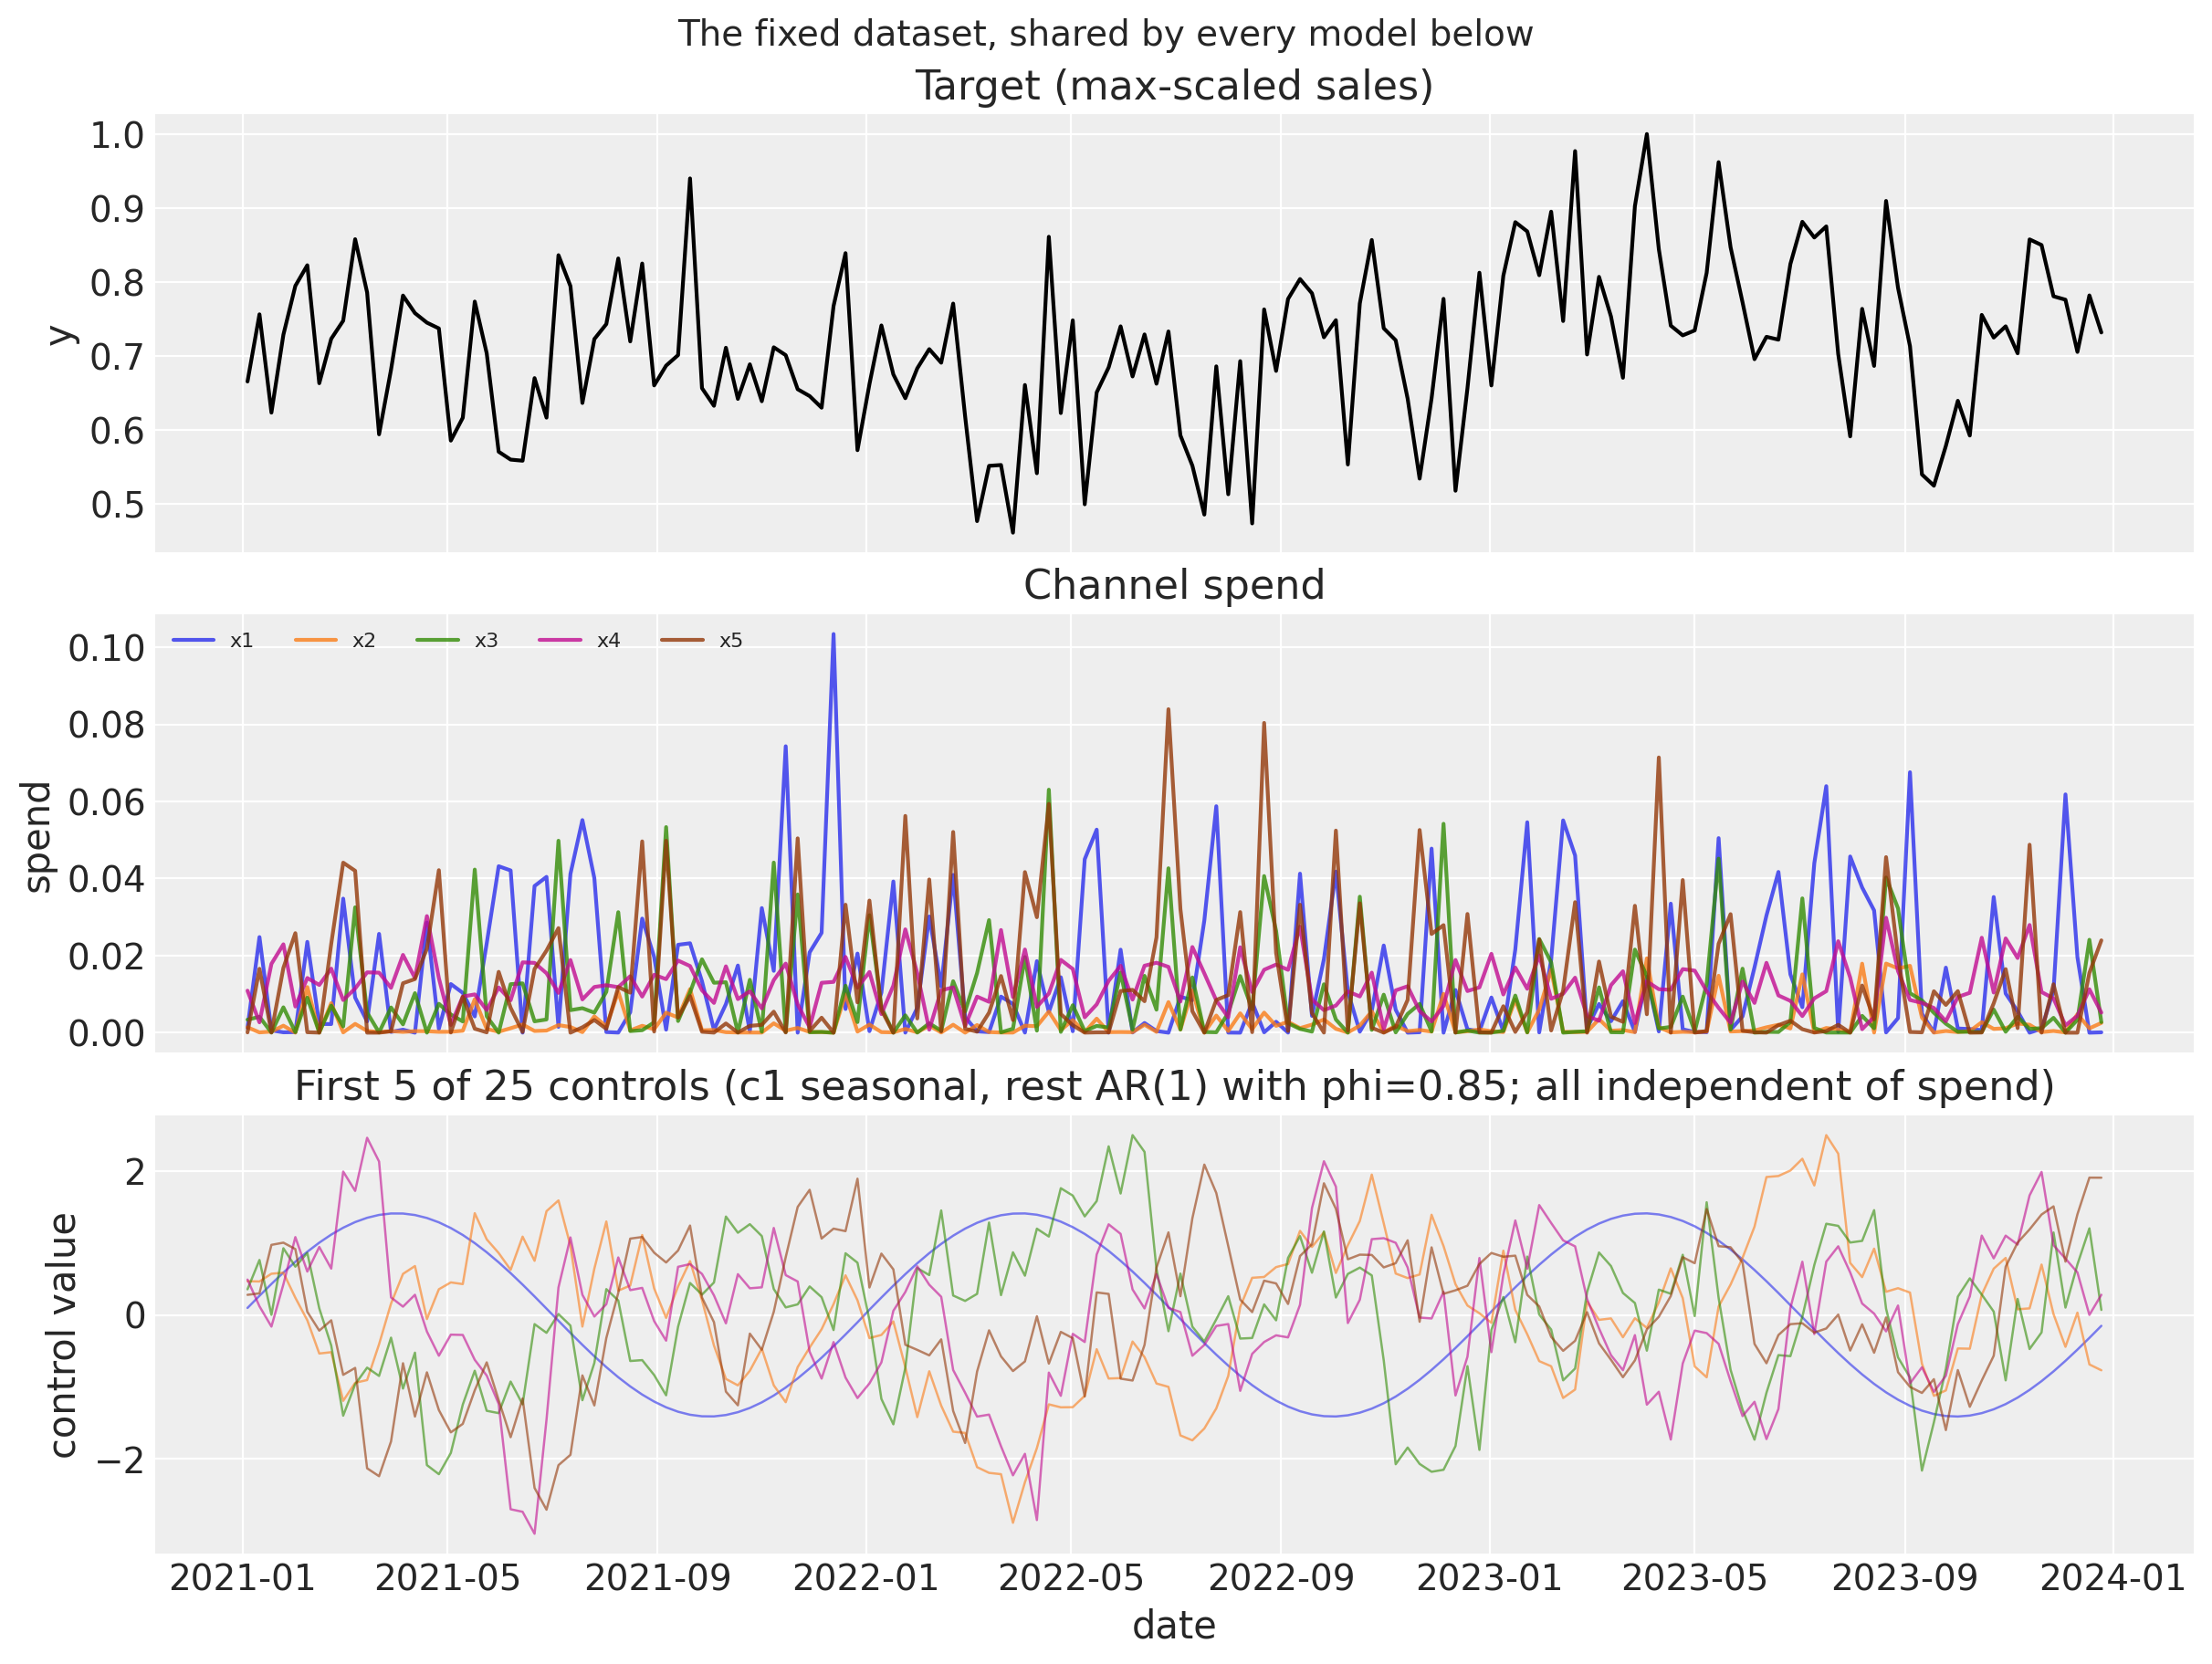

In [8]:
fig, axes = plt.subplots(nrows=3, figsize=(12, 9), sharex=True, layout="constrained")

sns.lineplot(x="date", y="y", data=data, color="black", ax=axes[0])
axes[0].set(title="Target (max-scaled sales)", ylabel="y")

for channel in CHANNELS:
    sns.lineplot(x="date", y=channel, data=data, ax=axes[1], label=channel, alpha=0.8)
axes[1].set(title="Channel spend", ylabel="spend")
axes[1].legend(ncol=5, loc="upper left", fontsize=8)

for control_name in CONTROLS[:5]:
    sns.lineplot(
        x="date", y=control_name, data=data, ax=axes[2], alpha=0.6, linewidth=0.9
    )
axes[2].set(
    title=(
        f"First 5 of {K_MAX} controls "
        f"(c1 seasonal, rest AR(1) with phi={CONTROL_PHI}; all independent of spend)"
    ),
    ylabel="control value",
    xlabel="date",
)

fig.suptitle("The fixed dataset, shared by every model below", fontsize=14)
plt.show()

Because importance decays, the $K$ grid is not a grid of equal steps in information. The cumulative share of control variance below makes that concrete: the first handful of columns carry most of the control signal and the tail adds very little. Under the Normal prior, though, every column in that tail costs exactly as much prior variance as the informative ones at the head did.

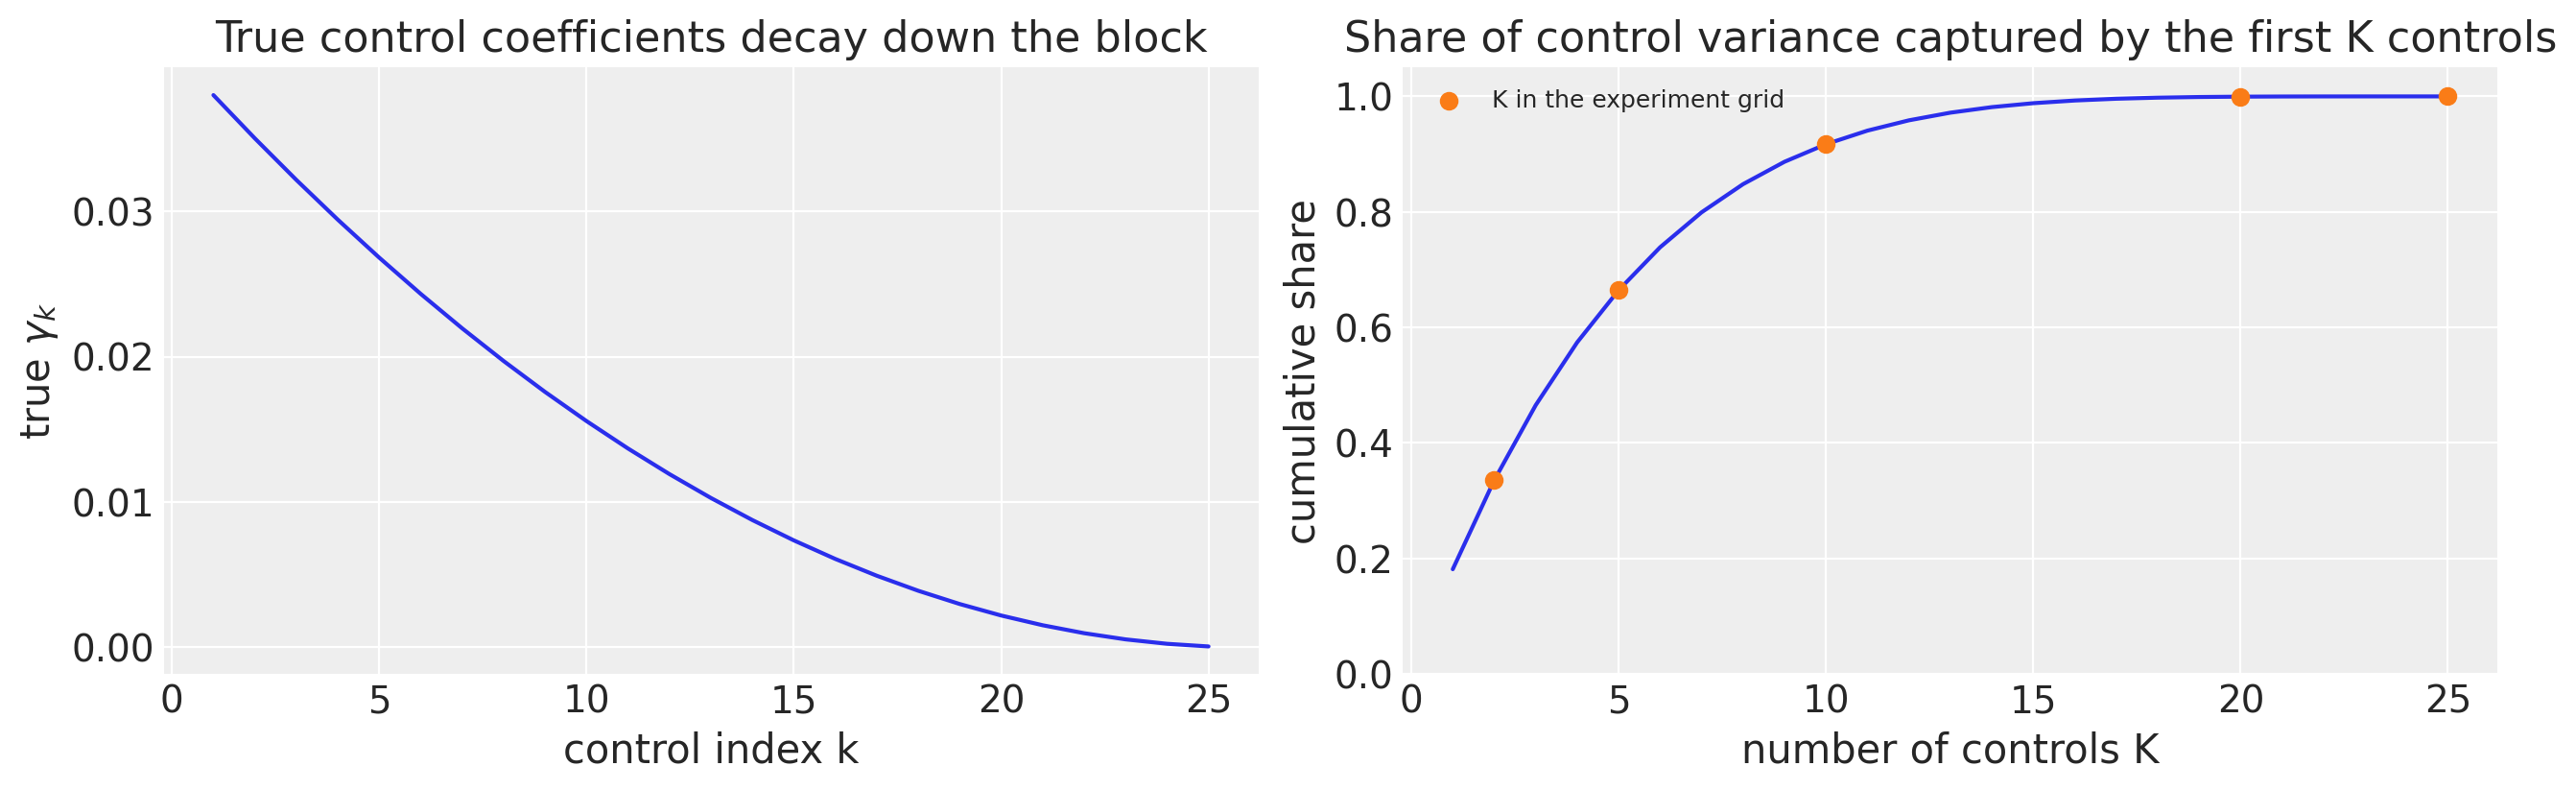

In [9]:
gamma_true = truth["gamma_control"]
cumulative_share = np.cumsum(gamma_true**2) / np.sum(gamma_true**2)

fig, axes = plt.subplots(ncols=2, figsize=(13, 4), layout="constrained")

axes[0].plot(np.arange(1, K_MAX + 1), gamma_true, color="C0")
axes[0].set(
    xlabel="control index k",
    ylabel=r"true $\gamma_k$",
    title="True control coefficients decay down the block",
)

axes[1].plot(np.arange(1, K_MAX + 1), cumulative_share, color="C0")
axes[1].scatter(
    [k for k in K_GRID if k > 0],
    [cumulative_share[k - 1] for k in K_GRID if k > 0],
    color="C1",
    zorder=3,
    label="K in the experiment grid",
)
axes[1].set(
    xlabel="number of controls K",
    ylabel="cumulative share",
    title="Share of control variance captured by the first K controls",
    ylim=(0, 1.05),
)
axes[1].legend(fontsize=9)

plt.show()

## The control priors

Three arms, and only two ideas: an independent Normal at the library default scale, the same Normal tightened by hand, and R2D2. The two Normal arms are there to separate *scale* from *dimension* — if tightening `sigma` were enough, they would differ.

All three slot into `model_config["gamma_control"]`, which is the whole point: the media priors are untouched **by construction**, which is what makes the third one a *split* prior rather than a joint one. No `MuEffect` subclass and no changes to the `MMM` class are needed.

Here is the code path they feed into. `gamma_control` is created, multiplied by the control data, summed over controls, and added to `mu`:

```python
if self.control_columns is not None and len(self.control_columns) > 0:
    gamma_control = self.model_config["gamma_control"].create_variable(
        name="gamma_control", xdist=True
    )
    control_data_ = pmd.Data("control_data", self.xarray_dataset._control)
    control_contribution = pmd.Deterministic(
        "control_contribution", control_data_ * gamma_control
    )
    mu_var += control_contribution.sum(dim="control")
```

### 1. Normal

The library default is `Prior("Normal", mu=0, sigma=2, dims="control")`. Note what is missing: `sigma` does not depend on $K$. The prior variance the control block expects to explain is $K \sigma^2$, growing without bound as controls are added.

Comparing R2D2 against that default would be both unfair and uninformative. On a max-scaled target `sigma=2` is so diffuse that the implied prior $R^2$ is pinned at 1 almost immediately, and *any* prior looks good next to one that has already declared the model explains everything. So we give the Normal prior the benefit of a modeller who has noticed that the default is too wide for a max-scaled target and has tightened it by hand.

`SIGMA_NORMAL = 0.1` is the value you land on by reasoning about **scale**: the target is max-scaled into roughly $[0.4, 1]$, a decent model should leave a residual of order 0.1, so an individual control coefficient of order 0.1 is plausible and one of order 1 is not. We use the same 0.1 for the residual scale prior (`SIGMA_REF`), so the coefficient prior and the expected residual are stated on a common footing.

This is a real improvement in the prior — it drops the implied prior $R^2$ at $K = 25$ from 1.000 to 0.984 — and it is the honest comparison to make, because tightening a too-wide default is exactly what a careful practitioner does. But note what it is *not*: reasoning about scale is not reasoning about **dimension**. `SIGMA_NORMAL` is still a constant, so the block's total budget is still $K \sigma^2$. Keeping both arms means that everything we attribute to dimension-awareness later has to survive a 20-fold change in coefficient scale, which turns out to be a much sterner test of the story than comparing against the default alone.

In [10]:
SIGMA_REF = 0.1  # prior scale for the residual sigma, on the scaled-target scale
SIGMA_NORMAL = 0.1  # hand-tightened Normal prior on the control coefficients

print(f"Normal control sigma: {SIGMA_NORMAL} (library default is 2)")
print(f"implied control block budget K * sigma^2 at K=25: {25 * SIGMA_NORMAL**2:.3f}")

Normal control sigma: 0.1 (library default is 2)
implied control block budget K * sigma^2 at K=25: 0.250


### 3. Split R2D2

`gamma_control` is consumed through `create_variable(name="gamma_control", xdist=True)`, and `pymc_marketing.special_priors` already defines a `SpecialPrior` ABC for priors that behave like `Prior` but need custom graph construction — `LaplacePrior` and `LogNormalPrior` are the shipped examples. A new subclass only needs `_checks` and `create_variable`.

The construction, following `r2_normal.stan` from the paper's reference implementation:

$$
R^2 \sim \text{Beta}\!\left(\bar{r}\,\kappa,\ (1-\bar{r})\,\kappa\right), \qquad
\tau^2 = \frac{R^2}{1 - R^2}, \qquad
\psi \sim \text{Dirichlet}(a \mathbf{1}_K), \qquad
\gamma_k = z_k \sqrt{\sigma^2 \tau^2 \psi_k},\quad z_k \sim \mathcal{N}(0, 1),
$$

where $\sigma$ is the model's own residual scale — the same variable the likelihood uses.

This is the mechanism that matters: $\sigma^2 \tau^2$ is a **fixed** variance budget, and the Dirichlet weights $\psi$ split it among however many controls there are. The total control variance therefore does not grow with $K$. We obtain the Dirichlet through the unnormalised-Gamma trick (draw Gammas, divide by their sum), lifted straight from the reference Stan model, which avoids needing a Dirichlet over a named dim.

The class defaults follow the paper's `config.yaml`: `r2_mean = 1/3` and `r2_precision = 3`, giving $\text{Beta}(1, 2)$, with a symmetric Dirichlet concentration of 1.

#### Choosing the Beta

We override those defaults with `r2_mean = 0.6` and `r2_precision = 22`, i.e. $\text{Beta}(13.2, 8.8)$, which puts 95% of its mass in $[0.39, 0.79]$. The paper's $\text{Beta}(1, 2)$ is close to uninformative on the unit interval; this one is a statement, and it is the kind of statement an MMM analyst is in a position to make. Read it in the units of the previous section: *the controls should account for most of what media leaves behind, but not all of it, and I would be surprised by either 0.3 or 0.9.* The truth for this dataset is 0.692, comfortably inside that range but nowhere near its centre, so the prior is informative without being handed the answer.

This is where the honesty of a shrinkage prior lives. A budget prior only shrinks while it is more confident than the data; make it vague and it will simply widen to accommodate whatever the likelihood prefers, which is the correct behaviour and also no help at all when the likelihood is the thing you are worried about.

#### The $\sigma^2$ is not decoration

It is tempting to drop the $\sigma^2$ and use a fixed plug-in guess for the residual scale, since the MMM max-scales its target and so a reasonable guess is available. That does preserve the property this experiment turns on — the budget is still fixed in $K$ — but it no longer implements a prior on $R^2$, and the damage is not small.

$R^2$ is a statement about explained variance *relative to* residual variance. Conditional on $\sigma$, a plug-in $\sigma_{\text{ref}}$ implies a median control $R^2$ of $\sigma_{\text{ref}}^2\tau^2 / (\sigma_{\text{ref}}^2\tau^2 + \sigma^2)$, which equals the intended Beta median only when $\sigma$ happens to equal $\sigma_{\text{ref}}$. These models settle around $\sigma \approx 0.057$, and at $\sigma_{\text{ref}} = 0.1$ that inflates the variance budget by $(0.1/0.057)^2 \approx 3.1\times$, pushing the implied control $R^2$ from the 0.60 we asked for up to about 0.82. Having just gone to the trouble of stating an informative belief, we would be quietly overriding it by a factor that depends on a quantity we do not know in advance. Wiring in the real $\sigma$ makes the implied $R^2$ the Beta we asked for, whatever residual scale the data turn out to imply.

#### Getting hold of the residual scale

The obstacle is ordering. `MMM.build_model` creates `gamma_control` well before it creates the likelihood, and `y_sigma` does not exist until the likelihood is built — so the control prior cannot simply look the variable up. A `MuEffect` does not help either: mu effects are also added to `mu` before the likelihood exists.

The way through is to notice that `Prior` treats **any** object with a `create_variable` method as a parameter factory — it does not have to be a `Prior`. So one small object can create `y_sigma` on first use and return that same variable on every later call, and we can place that one instance both in `model_config["likelihood"]` and inside the control prior. Whichever is built first creates the variable; the other finds it on the model. Because the lookup goes through `pm.modelcontext`, a single instance is safe to reuse across many models — nothing is cached on the object itself.

#### Why not wrap `pymc_extras`?

`pymc_extras.distributions.R2D2M2CP` implements a richer relative of this prior, so the honest first move is to try wrapping it. Most of the obstacles you would expect turn out not to be obstacles at all:

- **The plumbing works.** It returns `(residual_sigma, coefficients)`, and a `create_variable` wrapper can only return one variable — but the `SharedScale` object below exists precisely to let one variable reach two consumers, so handing `residual_sigma` to the likelihood is the problem it already solves.
- **The extra machinery degenerates cleanly.** With the default `positive_probs=0.5` the correlation-probability component reduces exactly to a mean-zero Normal, so wrapping it would not silently import a different model.
- **The dims mismatch is minor.** It builds plain `pm.*` variables in a nested submodel, naming the free variables `gamma_control::r2`, `gamma_control::phi` and `gamma_control::raw` while the returned Deterministic is plain `gamma_control` — which is the name the MMM wants. One `as_xtensor` call bridges the rest.

What does not work is the parameterisation, and no amount of wrapping fixes it. `R2D2M2CP` takes the **total** outcome standard deviation as a fixed input and *derives* the residual from it, `eps = sqrt(1 - r2) * output_sigma`. Its $R^2$ therefore means "explained by this block, out of the total", which is correct when the block is the entire linear predictor and wrong when media sits alongside it. Passing `y.std()` would assert that the target's variance is control variance plus noise, with media's 19% unaccounted for, and the residual scale handed to the likelihood would come out too large by a factor of about 1.3 — correctable only by moving `r2`, which moves the control budget at the same time.

Nor can you sidestep it by discarding `eps` and passing the shared residual scale in the `output_sigma` slot. The budget would then be $r_2\sigma^2$ rather than the $\tau^2\sigma^2 = \frac{R^2}{1-R^2}\sigma^2$ that R2D2 calls for, so asking for 0.6 would quietly assert a control $R^2$ of $0.6/1.6 = 0.375$. Recovering 0.6 would mean passing $\tau^2 = 1.5$ through an argument that is a Beta mean, constrained to $(0, 1)$. It is not expressible.

```{warning}
If you do reach for `R2D2M2CP`, note that its defaults do not give you R2D2. Leaving `variables_importance=None` makes the variance weights a vector of ones rather than a Dirichlet, so the total coefficient variance grows *linearly in $K$* — 0.08 at $K = 5$, 0.47 at $K = 25$, 1.92 at $K = 100$, which is the exact pathology this notebook is about. And leaving `r2_std=None` keeps $R^2$ a constant, so there is no prior on the fit at all. You need `variables_importance=np.ones(K)` and an explicit `r2_std` (0.1022 reproduces our $\text{Beta}(13.2, 8.8)$) before the budget is flat in $K$.
```

For the split case, then, the ten lines below are the shorter route.

In [11]:
class SharedScale:
    """Create one variable per model and hand the same one to every consumer.

    ``Prior`` treats any object exposing ``create_variable`` as a parameter
    factory, so the same instance can sit in ``model_config["likelihood"]`` and
    inside another prior: whichever is built first creates the variable, the
    other looks it up on the model.  The lookup goes through the active model
    context rather than instance state, so one instance is safe to reuse across
    any number of models.

    Parameters
    ----------
    prior : Prior
        Prior used the first time the variable is needed.
    name : str
        Name to create the variable under, and to look it up by.
    """

    def __init__(self, prior: Prior, name: str = "y_sigma") -> None:
        self.prior = prior
        self.name = name
        self.dims = prior.dims

    def create_variable(self, name: str | None = None, xdist: bool = False):
        """Return this model's variable, creating it on first use."""
        model = pm.modelcontext(None)
        if self.name in model.named_vars:
            return as_xtensor(model[self.name])

        return self.prior.create_variable(self.name, xdist=xdist)

    def to_dict(self) -> dict:
        """Serialize, so models using this in `model_config` stay saveable."""
        return {"shared_scale": self.name, "prior": self.prior.to_dict()}


class R2D2Prior(SpecialPrior):
    r"""R2D2 prior: a fixed coefficient-variance budget, split across coefficients.

    An :math:`R^2` prior is converted into a total coefficient variance
    :math:`\sigma^2 \tau^2` with :math:`\tau^2 = R^2 / (1 - R^2)`, which a
    Dirichlet then splits across the coefficients.  Because the budget is fixed,
    adding coefficients divides the same variance more finely instead of
    inflating the total.

    Parameters
    ----------
    dims : tuple of str
        Dims of the coefficient vector.  The budget is split across the last one.
    r2_mean : float
        Prior mean of :math:`R^2`.
    r2_precision : float
        Precision of the Beta prior on :math:`R^2`; larger is tighter.
    concentration : float
        Symmetric Dirichlet concentration.  1.0 is uniform over the simplex.
    sigma : float or SharedScale
        Residual scale the budget is stated relative to.  Pass a
        :class:`SharedScale` wrapping the likelihood's own scale to make this a
        prior on :math:`R^2`; a float makes it a prior on an absolute budget.
    """

    def __init__(
        self,
        dims: tuple | None = None,
        centered: bool = True,
        *,
        r2_mean: float = 1 / 3,
        r2_precision: float = 3.0,
        concentration: float = 1.0,
        sigma: float | SharedScale = 0.1,
    ) -> None:
        super().__init__(
            dims=dims,
            centered=centered,
            r2_mean=r2_mean,
            r2_precision=r2_precision,
            concentration=concentration,
            sigma=sigma,
        )

    def _checks(self) -> None:
        expected = {"r2_mean", "r2_precision", "concentration", "sigma"}
        if set(self.parameters) != expected:
            raise ValueError(f"Parameters must be {sorted(expected)}")
        if not self.dims:
            raise ValueError(
                "R2D2Prior needs at least one dim to split the budget over"
            )

    def create_variable(self, name: str, xdist: bool = False):
        """Build the R2D2 graph and return the coefficient vector."""
        if not xdist:
            raise NotImplementedError(f"{self!r} only supports xdist=True")

        r2_mean = self.parameters["r2_mean"]
        r2_precision = self.parameters["r2_precision"]
        split_dim = self.dims[-1]

        sigma = self._create_parameter("sigma", self.parameters["sigma"], name, True)

        r2 = pmd.Beta(
            f"{name}_r2",
            alpha=r2_mean * r2_precision,
            beta=(1.0 - r2_mean) * r2_precision,
        )
        weights_raw = pmd.Gamma(
            f"{name}_weights_raw",
            alpha=self.parameters["concentration"],
            beta=1.0,
            dims=self.dims,
        )
        weights = weights_raw / weights_raw.sum(split_dim)
        tau2 = sigma**2 * r2 / (1.0 - r2)
        offset = pmd.Normal(f"{name}_offset", mu=0.0, sigma=1.0, dims=self.dims)

        return pmd.Deterministic(name, offset * pmd.math.sqrt(tau2 * weights))


SHARED_SIGMA = SharedScale(Prior("HalfNormal", sigma=SIGMA_REF))

# Beta(13.2, 8.8): mean 0.6, 95% of the mass in [0.39, 0.79].  An analyst who
# thinks the controls should account for most, but not all, of what media leaves
# behind, and is willing to say so before seeing the data.
R2_MEAN = 0.6
R2_PRECISION = 22.0

r2_alpha, r2_beta = R2_MEAN * R2_PRECISION, (1 - R2_MEAN) * R2_PRECISION
r2_draws = Prior("Beta", alpha=r2_alpha, beta=r2_beta).sample_prior(
    draws=20_000, random_seed=SEED
)["variable"]
lower, upper = (float(r2_draws.quantile(q)) for q in (0.025, 0.975))
print(f"Beta({r2_alpha:.1f}, {r2_beta:.1f}) on the control block's R^2")
print(f"  median {float(r2_draws.median()):.2f}, 95% [{lower:.2f}, {upper:.2f}]")
print(f"  truth for this dataset: {truth['control_r2']:.2f}")

Sampling: [variable]


Beta(13.2, 8.8) on the control block's R^2
  median 0.60, 95% [0.39, 0.79]
  truth for this dataset: 0.69


A quick check that it builds and samples, and that the budget it implies does not grow with $K$ — which is the entire claim. Note that `sample_prior` works even though there is no likelihood here: `SharedScale` finds no `y_sigma` on the throwaway model and so creates it, which is exactly the fallback we want.

The natural thing to report is the budget *relative to* the residual variance, $\sum_k \gamma_k^2 / \sigma^2 = \tau^2 \sum_k \psi_k z_k^2$, since that is the dimensionless quantity the $R^2$ prior actually pins down. Its expectation is $\mathbb{E}[\tau^2] = \alpha / (\beta - 1) = 13.2 / 7.8 = 1.69$, which is what the mean column should reproduce.

Two features of the numbers below are worth anticipating so they are not mistaken for the thing we are testing. The ratio is right-skewed, so its median (1.2 to 1.5) sits below its mean. And the implied control $R^2$ climbs mildly with $K$, from 0.547 to 0.595, approaching the $\text{Beta}(13.2, 8.8)$ median of 0.604 from below: $\sum_k \psi_k z_k^2$ has mean 1 for every $K$ but only *concentrates* on 1 as $K$ grows, so at small $K$ the realised budget is usually smaller than the intended one. Neither is growth in the budget itself. Contrast the Normal prior, whose block budget $K\sigma^2$ goes from 0.02 at $K = 2$ to 0.25 at $K = 25$.

In [12]:
R2D2_CONTROL = R2D2Prior(
    dims=("control",),
    sigma=SHARED_SIGMA,
    r2_mean=R2_MEAN,
    r2_precision=R2_PRECISION,
)

for k in [5, 25, 100]:
    draws = R2D2_CONTROL.sample_prior(
        coords={"control": [f"c{i + 1}" for i in range(k)]},
        name="gamma_control",
        draws=2_000,
        random_seed=SEED,
    )
    budget = (draws["gamma_control"] ** 2).sum("control")
    ratio = budget / draws["y_sigma"] ** 2
    implied_r2 = budget / (budget + draws["y_sigma"] ** 2)
    print(
        f"K={k:4d}  budget/sigma^2: mean={float(ratio.mean()):6.3f} "
        f"median={float(ratio.median()):5.3f}   "
        f"implied control R^2 median={float(implied_r2.median()):.3f}"
    )

Sampling: [gamma_control_offset, gamma_control_r2, gamma_control_weights_raw, y_sigma]


Sampling: [gamma_control_offset, gamma_control_r2, gamma_control_weights_raw, y_sigma]


K=   5  budget/sigma^2: mean= 1.705 median=1.209   implied control R^2 median=0.547


Sampling: [gamma_control_offset, gamma_control_r2, gamma_control_weights_raw, y_sigma]


K=  25  budget/sigma^2: mean= 1.688 median=1.425   implied control R^2 median=0.588


K= 100  budget/sigma^2: mean= 1.684 median=1.469   implied control R^2 median=0.595


### Two honest caveats

**"$R^2$" here means the control block against the residual, not the model's $R^2$.** Because this is a *split* prior, the media contribution sits outside the budget entirely: the Beta governs $\operatorname{Var}(\text{control}) / (\operatorname{Var}(\text{control}) + \sigma^2)$, with media excluded from both numerator and denominator. So `r2_mean = 0.6` is not a claim that the model explains 60% of the target's variance; it is a claim about how much of what media leaves behind the controls should be allowed to take. Confusing the two would make the number look far too pessimistic for an MMM. A prior on the model's actual $R^2$ is the *joint* version, which shrinks media too, and which the paper finds considerably worse.

**R2D2 assumes standardised covariates** (footnote 7 of the paper). Ours are standardised by construction, which matters more here than in a plain regression because `MMM` does not scale controls itself. With controls on wildly different scales, a single shared budget is not meaningful — standardise them before using this prior.

## Model configuration

Everything except `gamma_control` is held identical across every fit. The priors are stated on the scaled-target scale, where the target lies in roughly $[0.4, 1]$: this is worth being explicit about, because the library defaults (`intercept` and `gamma_control` at `sigma=2`, likelihood `sigma` at `HalfNormal(2)`) are extremely diffuse relative to a max-scaled target, and that diffuseness is a large part of the story.

```{note}
**The media priors are the distributions the truth was drawn from.** `Beta(1, 3)` on `adstock_alpha` and `Gamma(3, 1)` on `saturation_lam` are both the library defaults and the DGP's own draws, so the media block is favourably specified. That is deliberate: it removes media prior misspecification as a competing explanation for anything we observe downstream, leaving the control prior as the only moving part.

It is a real assumption, so it is worth knowing what relaxing it costs. Refitting everything with `Beta(2, 2)` and `Gamma(2, 0.4)` instead — wider, and centred away from the truth — roughly triples every ROAS error (the $K = 25$ absolute errors go from 0.36, 0.38 and 0.11 to 1.01, 0.94 and 0.63), inflates every interval by about 60%, and reintroduces divergences. What it does not change is the ranking: R2D2 still has the lowest error at every $K \ge 5$. So the conclusion about control priors survives, while none of the absolute numbers do.
```

In [13]:
BASE_CONFIG = {
    "intercept": Prior("Normal", mu=0.5, sigma=0.5),
    "adstock_alpha": Prior("Beta", alpha=1, beta=3, dims="channel"),
    "saturation_lam": Prior("Gamma", alpha=3, beta=1, dims="channel"),
    "saturation_beta": Prior("HalfNormal", sigma=0.25, dims="channel"),
    # SHARED_SIGMA rather than a plain Prior, so that the R2D2 control prior
    # below can state its budget relative to this same residual scale.
    "likelihood": Prior("Normal", sigma=SHARED_SIGMA, dims="date"),
}

CONTROL_PRIORS = {
    "Normal, default": Prior("Normal", mu=0, sigma=2, dims="control"),
    "Normal, tightened": Prior("Normal", mu=0, sigma=SIGMA_NORMAL, dims="control"),
    "Split R2D2": R2D2_CONTROL,
}

PRIOR_NAMES = list(CONTROL_PRIORS)
PRIOR_COLORS = dict(zip(PRIOR_NAMES, ["C3", "C1", "C0"], strict=True))

SAMPLER_CONFIG = {
    "draws": 1_000,
    "tune": 1_000,
    "chains": 4,
    "target_accept": 0.95,
    "nuts_sampler": "nutpie",
}

`target_accept=0.95` is applied to *every* fit, Normal and R2D2 alike, which keeps the comparison clean. R2D2 needs it more: $\tau^2 = R^2/(1-R^2)$ is a funnel, and sharing $\sigma$ with the likelihood couples that funnel to the residual scale.

The informative Beta helps here as a side effect. $\tau^2$ has a finite mean only for $\beta > 1$ and a finite variance only for $\beta > 2$, so the paper's $\text{Beta}(1, 2)$ sits right at the edge of having no variance at all, while $\text{Beta}(13.2, 8.8)$ is comfortably inside. Twelve of the sixteen fits below report zero divergences and none exceeds $\hat{R} = 1.01$.

`K = 0` must pass `control_columns=None`, not `[]`: the `MMM` constructor enforces `min_length=1` on that field.

In [14]:
def build_mmm(k: int, prior_name: str | None = None) -> MMM:
    """Build an MMM on the first `k` controls with the named control prior."""
    config = dict(BASE_CONFIG)
    if k > 0:
        config["gamma_control"] = CONTROL_PRIORS[prior_name]

    return MMM(
        date_column="date",
        channel_columns=CHANNELS,
        control_columns=CONTROLS[:k] if k > 0 else None,
        target_column="y",
        adstock=GeometricAdstock(l_max=L_MAX),
        saturation=LogisticSaturation(),
        model_config=config,
        sampler_config=SAMPLER_CONFIG,
    )

## The mechanism: implied prior $R^2$ against $K$

Before running any MCMC we can see the problem directly, from prior draws alone. This is the analogue of the left panel of Figure 4 in the paper, and it is by far the cheapest diagnostic in this notebook.

For each prior draw we decompose the variance of the linear predictor over time into a media part and a control part, and add the residual variance:

$$
R^2_{\text{media}} = \frac{\operatorname{Var}_t(\text{media})}{\operatorname{Var}_t(\text{media}) + \operatorname{Var}_t(\text{control}) + \sigma^2},
\qquad
R^2_{\text{control}} = \frac{\operatorname{Var}_t(\text{control})}{\cdots},
$$

so the two shares add to the implied prior $R^2$. Everything comes from `sample_prior_predictive`; no sampler is involved.

In [15]:
def prior_variance_shares(
    k: int, control_prior, draws: int = 2_000
) -> tuple[xr.DataArray, xr.DataArray]:
    """Media and control shares of implied prior variance, per prior draw."""
    config = dict(BASE_CONFIG)
    if k > 0:
        config["gamma_control"] = control_prior

    mmm = MMM(
        date_column="date",
        channel_columns=CHANNELS,
        control_columns=CONTROLS[:k] if k > 0 else None,
        target_column="y",
        adstock=GeometricAdstock(l_max=L_MAX),
        saturation=LogisticSaturation(),
        model_config=config,
    )
    mmm.build_model(data.drop(columns=["y"]), data["y"])

    var_names = ["channel_contribution", "y_sigma"]
    if k > 0:
        var_names.append("control_contribution")

    with mmm.model:
        prior = pm.sample_prior_predictive(
            draws=draws, var_names=var_names, random_seed=SEED
        ).prior.to_dataset()

    var_media = prior["channel_contribution"].sum("channel").var("date")
    var_control = (
        prior["control_contribution"].sum("control").var("date")
        if k > 0
        else xr.zeros_like(var_media)
    )
    total = var_media + var_control + prior["y_sigma"] ** 2

    return var_media / total, var_control / total

In [16]:
prior_records = []
for label, control_prior in CONTROL_PRIORS.items():
    for k in K_GRID:
        media, control = prior_variance_shares(k, control_prior)
        r2 = media + control
        prior_records.append(
            {
                "prior": label,
                "K": k,
                "r2_median": float(r2.median()),
                "r2_q05": float(r2.quantile(0.05)),
                "r2_q95": float(r2.quantile(0.95)),
                "media_share": float(media.median()),
                "control_share": float(control.median()),
            }
        )

prior_r2 = pd.DataFrame(prior_records)
prior_r2.round(3)

Sampling: [adstock_alpha, saturation_beta, saturation_lam, y_sigma]


Sampling: [adstock_alpha, gamma_control, saturation_beta, saturation_lam, y_sigma]


Sampling: [adstock_alpha, gamma_control, saturation_beta, saturation_lam, y_sigma]


Sampling: [adstock_alpha, gamma_control, saturation_beta, saturation_lam, y_sigma]


Sampling: [adstock_alpha, gamma_control, saturation_beta, saturation_lam, y_sigma]


...

Sampling: [adstock_alpha, gamma_control_offset, gamma_control_r2, gamma_control_weights_raw, saturation_beta, saturation_lam, y_sigma]


Sampling: [adstock_alpha, gamma_control_offset, gamma_control_r2, gamma_control_weights_raw, saturation_beta, saturation_lam, y_sigma]


Sampling: [adstock_alpha, gamma_control_offset, gamma_control_r2, gamma_control_weights_raw, saturation_beta, saturation_lam, y_sigma]


Sampling: [adstock_alpha, gamma_control_offset, gamma_control_r2, gamma_control_weights_raw, saturation_beta, saturation_lam, y_sigma]


,prior,K,r2_median,r2_q05,r2_q95,media_share,control_share
0,"Normal, default",0,0.697,0.123,0.997,0.697,0.000
1,"Normal, default",2,0.999,0.979,1.000,0.002,0.997
2,"Normal, default",5,1.000,0.997,1.000,0.001,0.999
3,"Normal, default",10,1.000,0.999,1.000,0.000,1.000
4,"Normal, default",20,1.000,0.999,1.000,0.000,1.000
5,"Normal, default",25,1.000,1.000,1.000,0.000,1.000
6,"Normal, tightened",0,0.697,0.123,0.997,0.697,0.000
7,"Normal, tightened",2,0.864,0.313,0.999,0.288,0.431
8,"Normal, tightened",5,0.932,0.511,0.999,0.151,0.706
9,"Normal, tightened",10,0.962,0.690,1.000,0.086,0.838


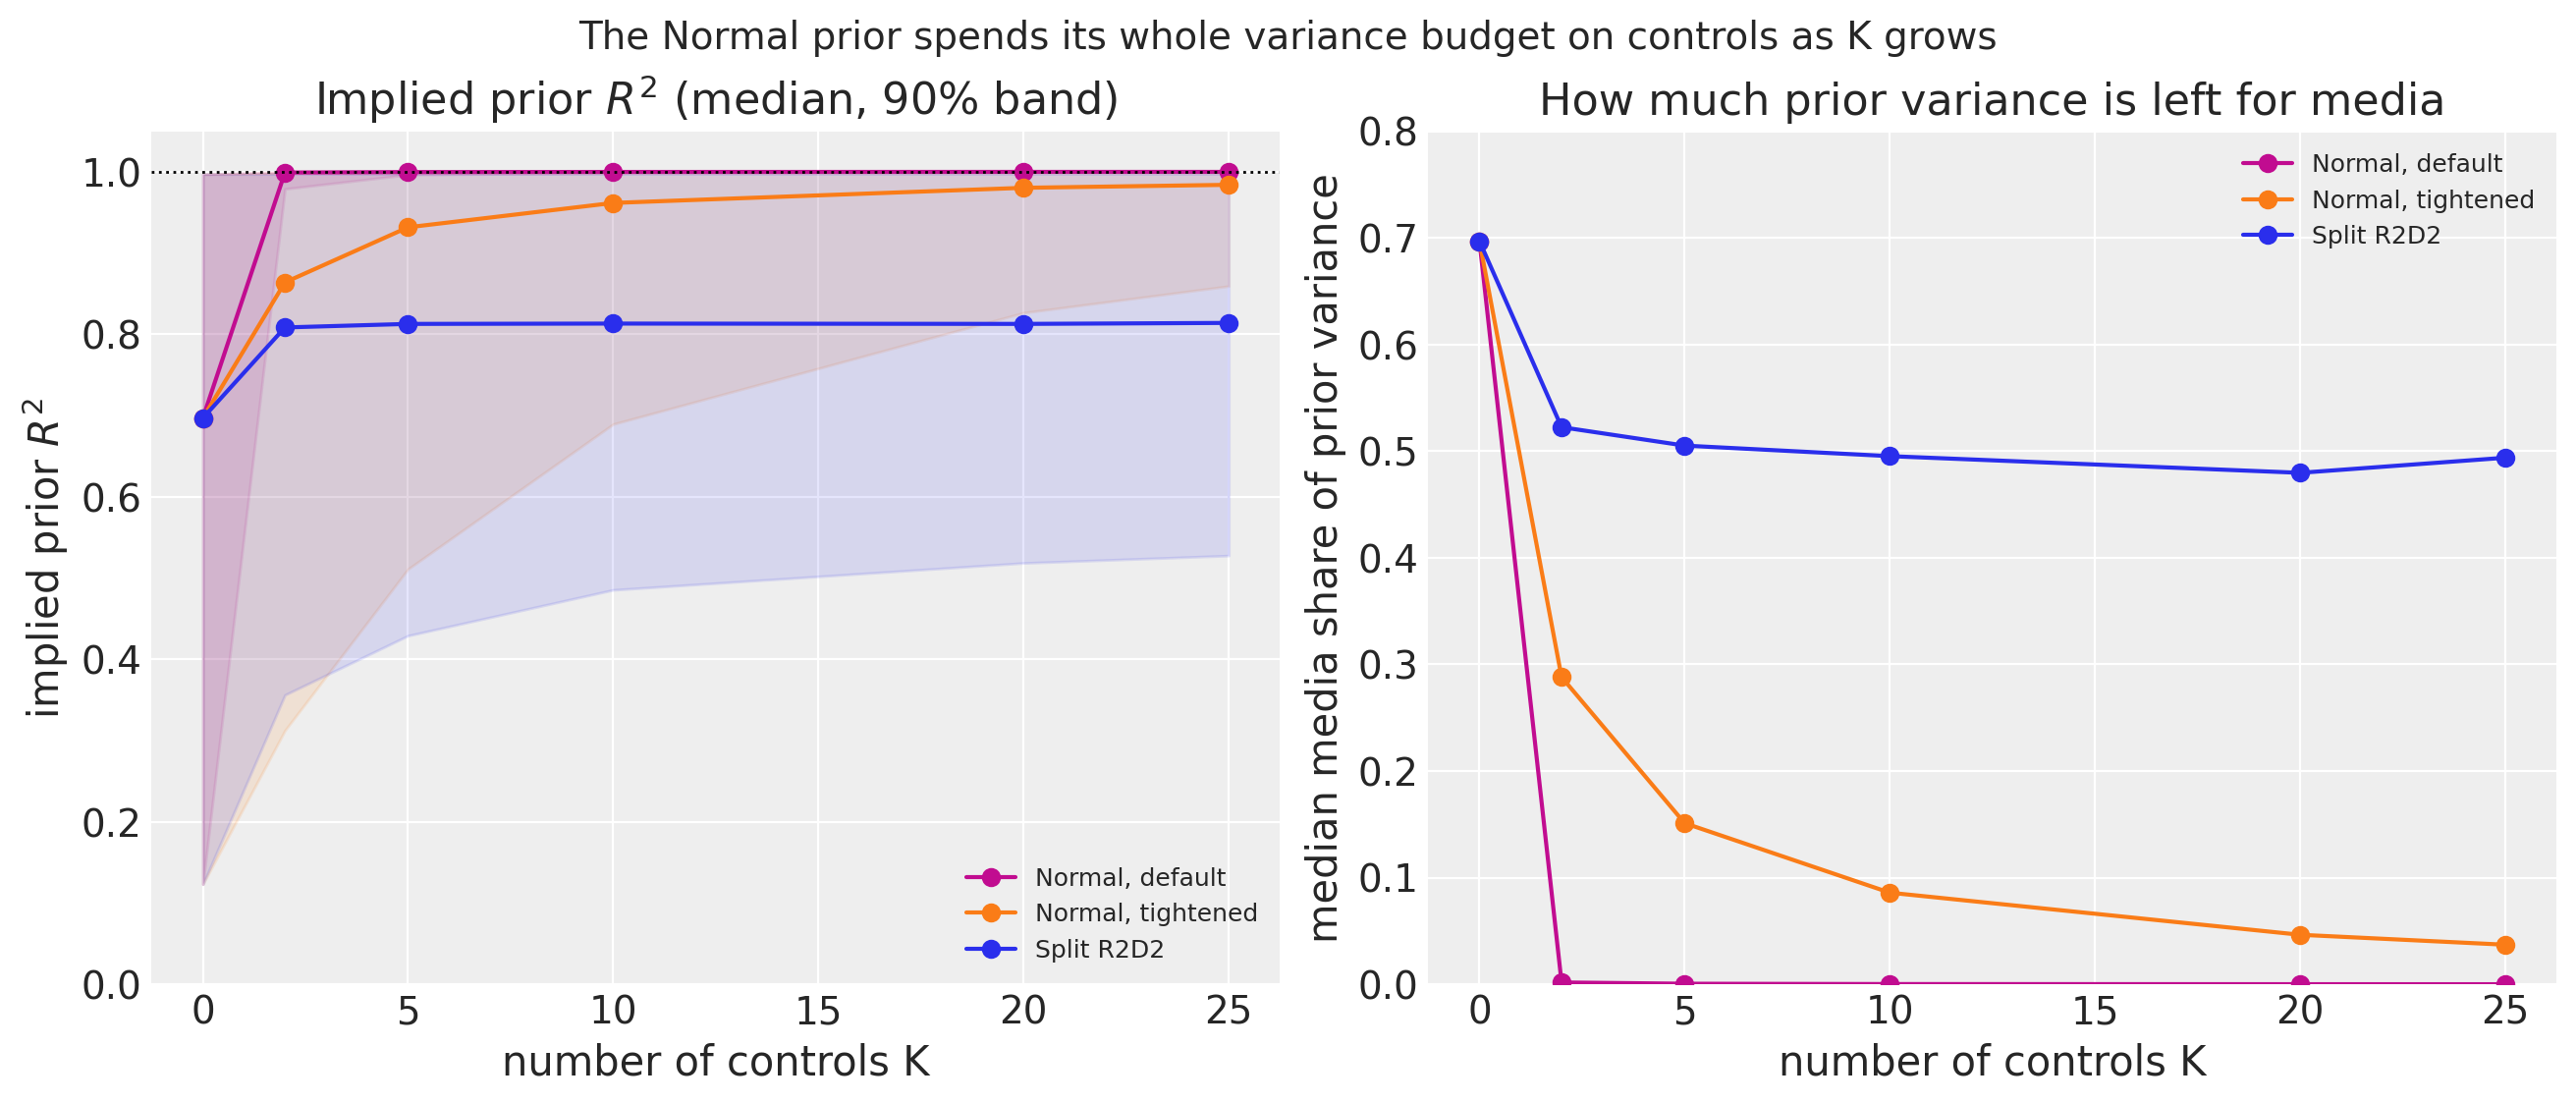

In [17]:
fig, axes = plt.subplots(ncols=2, figsize=(13, 5.5), sharex=True, layout="constrained")
colors = PRIOR_COLORS

for label in PRIOR_NAMES:
    subset = prior_r2.query("prior == @label")
    axes[0].plot(
        subset["K"], subset["r2_median"], marker="o", color=colors[label], label=label
    )
    axes[0].fill_between(
        subset["K"],
        subset["r2_q05"],
        subset["r2_q95"],
        color=colors[label],
        alpha=0.12,
    )

axes[0].axhline(1.0, color="black", linestyle=":", linewidth=1)
axes[0].set(
    xlabel="number of controls K",
    ylabel="implied prior $R^2$",
    title="Implied prior $R^2$ (median, 90% band)",
    ylim=(0, 1.05),
)
axes[0].legend(loc="lower right", fontsize=9)

for label in PRIOR_NAMES:
    subset = prior_r2.query("prior == @label")
    axes[1].plot(
        subset["K"],
        subset["media_share"],
        marker="o",
        color=colors[label],
        label=label,
    )

axes[1].set(
    xlabel="number of controls K",
    ylabel="median media share of prior variance",
    title="How much prior variance is left for media",
    ylim=(0, 0.8),
)
axes[1].legend(loc="upper right", fontsize=9)

fig.suptitle(
    "The Normal prior spends its whole variance budget on controls as K grows",
    fontsize=14,
)
plt.show()

All three priors start from the same place: at $K = 0$ there is no control block, so the implied prior $R^2$ has median 0.702 under all of them, set entirely by the media and residual priors.

Under the **library default** it jumps to 0.999 at $K = 2$ and is numerically 1 from $K = 5$ on. Before seeing a single data point, the prior asserts that the model explains everything. **Tightening by hand helps but does not fix it**: 0.863 at $K = 2$, 0.930 at $K = 5$, 0.984 by $K = 25$, climbing monotonically exactly as $K\sigma^2$ predicts. **R2D2 is flat** — 0.811, 0.814, 0.814, 0.810, 0.812 across the whole grid. The budget is fixed, so splitting it more finely does not change the total.

The right panel tells the same story from media's point of view, and it is the more alarming one. The share of prior variance left for media collapses from 0.702 to 0.037 under the tightened Normal — a factor of 19 — and to 0.000 under the default. Under R2D2 it goes from 0.702 to 0.489 and stops. A prior that has decided in advance that media explains essentially nothing is a prior that starts out unwilling to attribute revenue to media.

The share of prior variance handed to the *control block* is the cleanest way to see the gap open. At $K = 2$ it is 0.997, 0.427 and 0.152 for default, tightened and R2D2; at $K = 25$ it is 1.000, 0.931 and 0.273. R2D2's rises a little, because a longer Dirichlet realises its budget more reliably, but it rises by 0.12 where the tightened Normal's rises by 0.50. The difference is not that R2D2 begins stricter, it is that it stays where it began.

## The experiment

Now the posterior. Nested subsets $K \in$ `K_GRID` of the same pool of controls, so `y` is byte-identical across every fit. Each $K > 0$ is fit three times, once per control prior; $K = 0$ is fit once, since all three coincide when there are no controls. Everything else — media priors, seeds, sampler settings — is held identical.

Total ROAS per fit comes from the counterfactual machinery rather than from a contribution deterministic, so it is the same quantity a practitioner would report.

In [18]:
def total_roas(mmm: MMM) -> np.ndarray:
    """Posterior draws of total media ROAS over the whole fitted period."""
    incremental = mmm.incrementality.compute_incremental_contribution(
        frequency="all_time"
    )
    spend = float(mmm.data.get_channel_spend().sum())
    return (incremental.sum("channel") / spend).values.ravel()


def variance_shares(mmm: MMM, k: int) -> dict:
    """Posterior variance shares and implied posterior R^2 for a fitted model."""
    posterior = mmm.idata.posterior
    var_media = posterior["channel_contribution"].sum("channel").var("date")
    var_control = (
        posterior["control_contribution"].sum("control").var("date")
        if k > 0
        else xr.zeros_like(var_media)
    )
    total = var_media + var_control + posterior["y_sigma"] ** 2

    return {
        "media_share": float((var_media / total).mean()),
        "control_share": float((var_control / total).mean()),
        "posterior_r2": float(((var_media + var_control) / total).mean()),
    }


def level_shares(mmm: MMM, mean_target: float) -> dict:
    """Mean contribution of the media and intercept blocks, as a share of mean sales.

    Variance shares say how much each block *moves*; ROAS depends on how much
    each block *is*.  The two come apart when a control block soaks up level.
    """
    posterior = mmm.idata.posterior
    media = posterior["channel_contribution"].sum("channel").mean("date")

    return {
        "media_level_share": float(media.mean()) / mean_target,
        "intercept_level_share": float(posterior["intercept_contribution"].mean())
        / mean_target,
    }


def fit_for_k(
    dataset: pd.DataFrame, k: int, prior_name: str, seed: int
) -> tuple[np.ndarray, dict]:
    """Fit one (K, prior) cell and return ROAS draws plus fit diagnostics."""
    mmm = build_mmm(k, prior_name)
    mmm.fit(
        dataset.drop(columns=["y"]),
        dataset["y"],
        random_seed=seed,
        progressbar=False,
    )

    diagnostics = az.summary(
        mmm.idata.posterior,
        var_names=["intercept_contribution", "saturation_beta", "y_sigma"],
    )
    posterior = mmm.idata.posterior
    info = {
        "K": k,
        "prior": prior_name,
        "divergences": int(mmm.idata.sample_stats["diverging"].sum()),
        "max_r_hat": float(diagnostics["r_hat"].max()),
        "posterior_sigma": float(posterior["y_sigma"].mean()),
        # Posterior spread of a single control coefficient, and the R2D2 budget
        # the data end up asking for.  Both feed the shrinkage table below.
        "gamma_sd": float(posterior["gamma_control"].std(["chain", "draw"]).mean())
        if k > 0
        else np.nan,
        "r2_posterior": float(posterior["gamma_control_r2"].mean())
        if "gamma_control_r2" in posterior
        else np.nan,
    }
    info |= variance_shares(mmm, k)
    info |= level_shares(mmm, float(dataset["y"].mean()))

    return total_roas(mmm), info

The ground-truth check below is worth pausing on. It confirms that our analytic truth is *exactly* the quantity the MMM would report, by plugging the true parameters into the model graph with `pm.do` and reading off its own total media contribution. If the adstock `normalize` flag or the channel scaling were misaligned, this is where it would show up.

In [19]:
check_mmm = build_mmm(0)
check_mmm.build_model(data.drop(columns=["y"]), data["y"])
fixed = pm.do(
    check_mmm.model,
    {
        "intercept_contribution": truth["intercept"],
        "adstock_alpha": truth["adstock_alpha"],
        "saturation_lam": truth["saturation_lam"],
        "saturation_beta": truth["saturation_beta"],
    },
)
model_total = float(pm.draw(fixed["total_media_contribution_original_scale"]))

model_roas = model_total / spend_matrix.sum()

print(f"model-implied total ROAS at true parameters: {model_roas:.6f}")
print(f"analytic ground-truth total ROAS          : {truth['total_roas']:.6f}")

model-implied total ROAS at true parameters: 2.022148
analytic ground-truth total ROAS          : 2.022148


In [20]:
roas_draws: dict[tuple[int, str], np.ndarray] = {}
fit_records = []

for k in K_GRID:
    for prior_name in [PRIOR_NAMES[0]] if k == 0 else PRIOR_NAMES:
        draws, info = fit_for_k(data, k, prior_name, seed=SEED)
        roas_draws[k, prior_name] = draws
        fit_records.append(info)

fits = pd.DataFrame(fit_records)
fits.round(4)

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, y_sigma, intercept_contribution]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_control, y_sigma, intercept_contribution]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_control, y_sigma, intercept_contribution]


...

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_control, y_sigma, intercept_contribution]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_control_weights_raw, gamma_control_r2, y_sigma, gamma_control_offset, intercept_contribution]


Output()

,K,prior,divergences,max_r_hat,posterior_sigma,gamma_sd,r2_posterior,media_share,control_share,posterior_r2,media_level_share,intercept_level_share
0,0,"Normal, default",1,1.00,0.0973,NaN,NaN,0.2077,0.0000,0.2077,0.1272,0.8724
1,2,"Normal, default",5,1.01,0.0888,0.0075,NaN,0.2028,0.1455,0.3483,0.1328,0.8671
2,2,"Normal, tightened",4,1.00,0.0888,0.0077,NaN,0.2011,0.1434,0.3445,0.1304,0.8694
3,2,Split R2D2,0,1.01,0.0885,0.0075,0.5736,0.2038,0.1402,0.3440,0.1316,0.8685
4,5,"Normal, default",0,1.00,0.0738,0.0065,NaN,0.2019,0.3559,0.5577,0.1292,0.8708
5,5,"Normal, tightened",0,1.00,0.0738,0.0066,NaN,0.2022,0.3540,0.5562,0.1299,0.8701
6,5,Split R2D2,0,1.00,0.0739,0.0065,0.6059,0.2074,0.3349,0.5423,0.1270,0.8730
7,10,"Normal, default",0,1.00,0.0614,0.0061,NaN,0.2073,0.4958,0.7031,0.1545,0.8456
8,10,"Normal, tightened",0,1.00,0.0615,0.0060,NaN,0.2080,0.4929,0.7009,0.1547,0.8453
9,10,Split R2D2,0,1.00,0.0620,0.0061,0.6462,0.2122,0.4658,0.6780,0.1492,0.8507


For $K = 0$ all three priors coincide — there are no control coefficients to put a prior on — so the single $K = 0$ fit is shared by all three series. `by_prior` handles that relabelling once, for every table and figure below.

In [21]:
def roas_summary(draws: np.ndarray) -> dict:
    """Posterior summary of ROAS against the known truth."""
    q05, median, q95 = np.quantile(draws, [0.05, 0.5, 0.95])
    return {
        "q05": q05,
        "median": median,
        "q95": q95,
        "interval_length": q95 - q05,
        "covers_truth": bool(q05 <= truth["total_roas"] <= q95),
        "bias": float(draws.mean() - truth["total_roas"]),
        "squared_error": float((draws.mean() - truth["total_roas"]) ** 2),
    }


def by_prior(frame: pd.DataFrame, prior_name: str) -> pd.DataFrame:
    """One row per K for a single prior, treating the K=0 fit as shared."""
    rows = frame[(frame["prior"] == prior_name) | (frame["K"] == 0)].copy()
    return rows.assign(prior=prior_name).sort_values("K")


def roas_matrix(column: str) -> pd.DataFrame:
    """Pivot one ROAS summary column into a K-by-prior table."""
    return pd.concat(
        [
            by_prior(roas_table, name).set_index("K")[column].rename(name)
            for name in PRIOR_NAMES
        ],
        axis=1,
    )


roas_table = pd.DataFrame(
    [
        {"K": k, "prior": prior_name} | roas_summary(draws)
        for (k, prior_name), draws in roas_draws.items()
    ]
)
roas_table.round(4)

,K,prior,q05,median,q95,interval_length,covers_truth,bias,squared_error
0,0,"Normal, default",1.0618,1.6373,2.5430,1.4812,True,-0.3260,0.1063
1,2,"Normal, default",1.0719,1.6662,2.7531,1.6812,True,-0.2516,0.0633
2,2,"Normal, tightened",1.0792,1.6760,2.6349,1.5556,True,-0.2831,0.0801
3,2,Split R2D2,1.0952,1.6761,2.7053,1.6101,True,-0.2678,0.0717
4,5,"Normal, default",1.1735,1.6820,2.4055,1.2321,True,-0.2992,0.0895
5,5,"Normal, tightened",1.1612,1.6829,2.4756,1.3144,True,-0.2902,0.0842
6,5,Split R2D2,1.1434,1.6529,2.3740,1.2306,True,-0.3284,0.1079
7,10,"Normal, default",1.4483,2.0193,2.8239,1.3756,True,0.0372,0.0014
8,10,"Normal, tightened",1.4402,2.0295,2.7779,1.3377,True,0.0402,0.0016
9,10,Split R2D2,1.3681,1.9491,2.7460,1.3779,True,-0.0331,0.0011


### The headline figure: total ROAS across $K$

This is the analogue of Figure 9 in the paper. One posterior density per $K$, one column per prior, with the true ROAS and the $K = 0$ baseline marked.

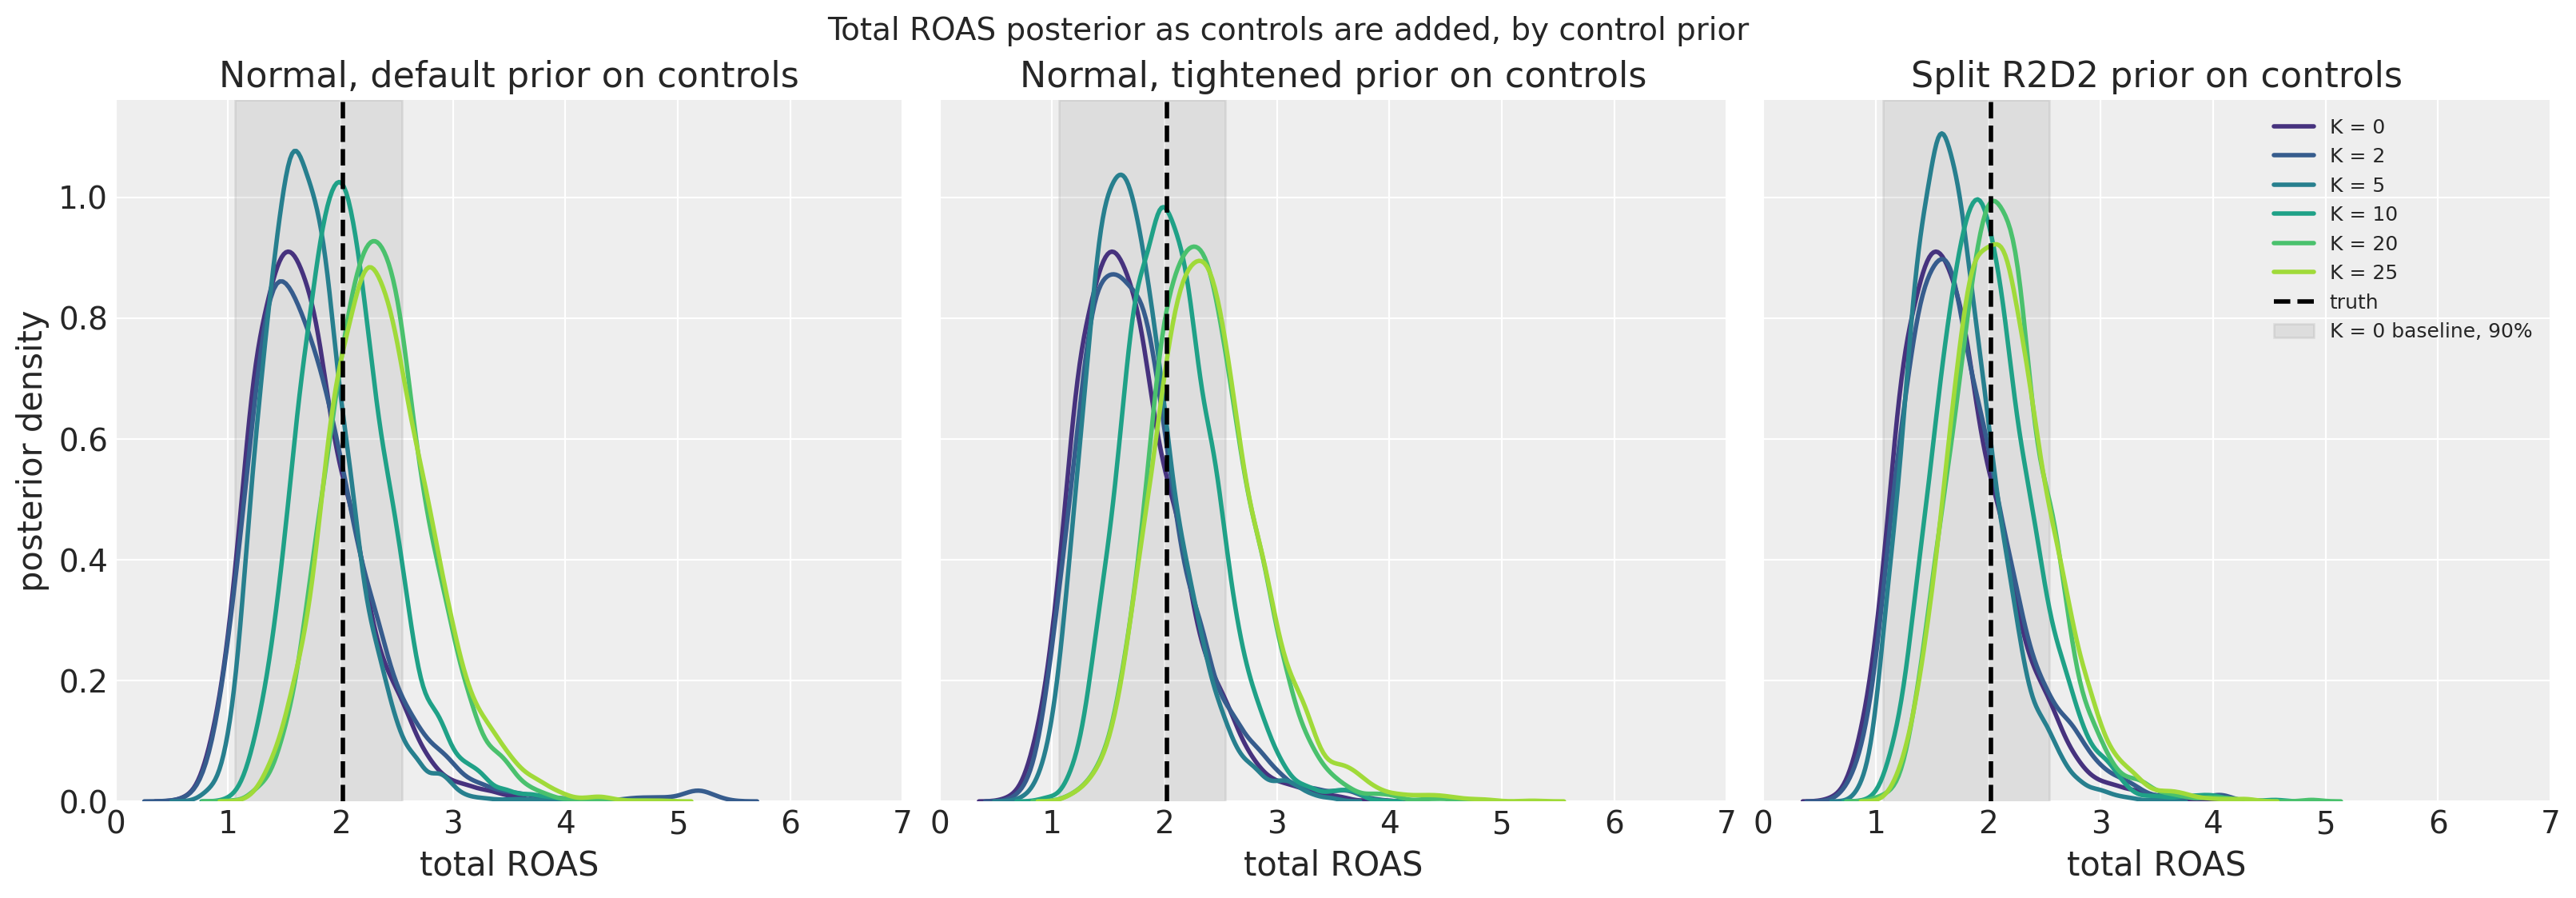

In [22]:
def series_for(prior_name: str) -> list[tuple[int, np.ndarray]]:
    """ROAS draws by K for one prior, reusing the shared K=0 fit."""
    return [
        (k, roas_draws[k, PRIOR_NAMES[0] if k == 0 else prior_name]) for k in K_GRID
    ]


baseline = roas_draws[0, PRIOR_NAMES[0]]
baseline_q05, baseline_q95 = np.quantile(baseline, [0.05, 0.95])

fig, axes = plt.subplots(
    ncols=len(PRIOR_NAMES),
    figsize=(16, 5.5),
    sharex=True,
    sharey=True,
    layout="constrained",
)
palette = sns.color_palette("viridis", n_colors=len(K_GRID))

for ax, prior_name in zip(axes, PRIOR_NAMES, strict=True):
    for (k, draws), color in zip(series_for(prior_name), palette, strict=True):
        sns.kdeplot(
            x=draws, ax=ax, color=color, linewidth=2, label=f"K = {k}", clip=(0, None)
        )
    ax.axvline(
        truth["total_roas"], color="black", linestyle="--", linewidth=2, label="truth"
    )
    ax.axvspan(
        baseline_q05,
        baseline_q95,
        color="gray",
        alpha=0.15,
        label="K = 0 baseline, 90%",
    )
    ax.set(xlabel="total ROAS", title=f"{prior_name} prior on controls", xlim=(0, 7))

axes[0].set_ylabel("posterior density")
axes[-1].legend(loc="upper right", fontsize=9)
fig.suptitle(
    "Total ROAS posterior as controls are added, by control prior", fontsize=14
)
plt.show()

The two Normal panels are the same picture; the R2D2 panel is not. At $K = 25$ the medians are 2.332, 2.352 and 2.095 against a true 2.022, and the first two are indistinguishable from each other despite a 20-fold difference in the coefficient scale that produced them. Whatever is happening is not about the size of `sigma`.

Read the panels left to right in $K$ rather than across in prior, and the shape of the result appears. At $K = 0$ every fit *under*-attributes to media, with a median of 1.637 against 2.022: the yearly cycle the model cannot see ends up in the residual, where it inflates $\sigma$ to 0.097 against a true 0.057 and leaves media's level short. The first ten controls repair that under every prior, and at $K = 10$ all three land within 0.04 of the truth. It is what happens *after* that separates them. The two Normal fits keep going in the same direction — 2.326 and 2.316 at $K = 20$, 2.332 and 2.352 at $K = 25$ — while R2D2 stops at 2.093 and 2.095. R2D2 also gives the narrowest interval at both of those $K$, so the accuracy is not bought with vagueness.

The comparison against $K = 0$ is the one that should give a practitioner pause. An absolute error of 0.358 at $K = 25$ under the default prior is no better than the 0.326 you get by including **no controls at all**, which is the paper's Table 4 finding in a media-mix setting. Twenty-five carefully ordered, genuinely informative, causally neutral controls, and the reported number is no closer to the truth than if you had skipped them — unless the prior on them is dimension-aware, in which case the error is 0.112 and the controls were well worth having.

### Why the priors matter here

Two conditions have to hold for a control prior to reach the reported number, and both are met at $K = 25$ in a way they would not be with iid controls.

**The likelihood no longer pins each coefficient on its own.** With standardised controls, $\sum_t c_{kt}^2 = n = 156$, so the naive likelihood-only standard deviation for a coefficient is $\sigma/\sqrt{n} = 0.0046$ at $\sigma = 0.057$. But the persistent columns are mutually correlated — mean $|\text{corr}|$ of 0.139 against 0.067 for white noise, and a maximum of 0.642 against 0.252 — and once you account for that the mean likelihood-only standard deviation across the 25 coefficients is 0.0070, a variance inflation factor of 2.35. The observed posterior standard deviation is 0.0073 under both Normal priors, i.e. the likelihood value: those priors are doing nothing. Under R2D2 it is 0.0062, about 15% tighter. R2D2 is the only one of the three that is contributing information.

**The control block has spare capacity that points at media.** Regressing the true media contribution on the first $K$ controls gives an $R^2$ of 0.082 at $K = 10$ but 0.242 at $K = 25$ — against 0.135 for a white-noise block of the same size. So the extra fifteen columns, whose true coefficients are nearly zero, are not harmless: collectively they can reproduce a quarter of the media signal. A budget prior limits exactly that, by capping what the block as a whole is allowed to be, and it does so without needing to know which columns are the culprits.

### Where the damage shows up

The natural guess is that the control block steals variance from media, and it is wrong. All three priors put media's share of target variance at 0.236 to 0.239, and all three overshoot the true 0.189 by about the same margin. On variance shares these fits are near-identical.

The disagreement is in the **level**. Media's share of mean sales comes out at 0.179 and 0.180 under the Normal priors, against 0.160 under R2D2 and a true 0.152. Those are the ROAS errors, restated: ROAS is total media contribution over total spend, so a level error is the whole story and a variance error is beside the point. The intercept takes the other side of the trade, dropping from a true 0.859 to 0.821 under the Normal priors against 0.840 under R2D2. The controls themselves take almost no level, since standardised columns are mean-zero by construction — what the block does is loosen the media/intercept split rather than compete for level directly.

This is the practical warning in the notebook. A control block that is overfitting shows up faintly in variance decompositions, faintly in $R^2$, not at all in the sampler diagnostics — and at full strength in the one number the model exists to produce.

The arithmetic behind the first of the two conditions above, priced out from the fits rather than asserted. Comparing the two likelihood-only standard deviations shows what the persistent columns cost in identification, and comparing those against the observed posterior spread shows which priors are contributing anything.

In [23]:
largest_k = max(K_GRID)
at_largest_k = fits.query("K == @largest_k").set_index("prior")
sigma_hat = float(at_largest_k["posterior_sigma"].mean())

design = np.column_stack([np.ones(N_DATES), control_matrix[:, :largest_k]])
coefficient_variance = np.diag(np.linalg.inv(design.T @ design))[1:]

print(f"K = {largest_k}, posterior sigma = {sigma_hat:.4f}")
print(
    f"  mean variance inflation factor:          {(coefficient_variance * N_DATES).mean():.2f}"
)
print(f"  likelihood-only sd, orthogonal columns:  {sigma_hat / np.sqrt(N_DATES):.4f}")
print(
    "  likelihood-only sd, these columns:      "
    f"{(sigma_hat * np.sqrt(coefficient_variance)).mean():.4f}"
)
for prior_name, gamma_sd in at_largest_k["gamma_sd"].items():
    print(f"  observed posterior sd, {prior_name:18s}{gamma_sd:.4f}")

K = 25, posterior sigma = 0.0578
  mean variance inflation factor:          2.35
  likelihood-only sd, orthogonal columns:  0.0046
  likelihood-only sd, these columns:      0.0070
  observed posterior sd, Normal, default   0.0073
  observed posterior sd, Normal, tightened 0.0073
  observed posterior sd, Split R2D2        0.0062


A more compact view of the headline result: interval length, and the posterior median against the truth.

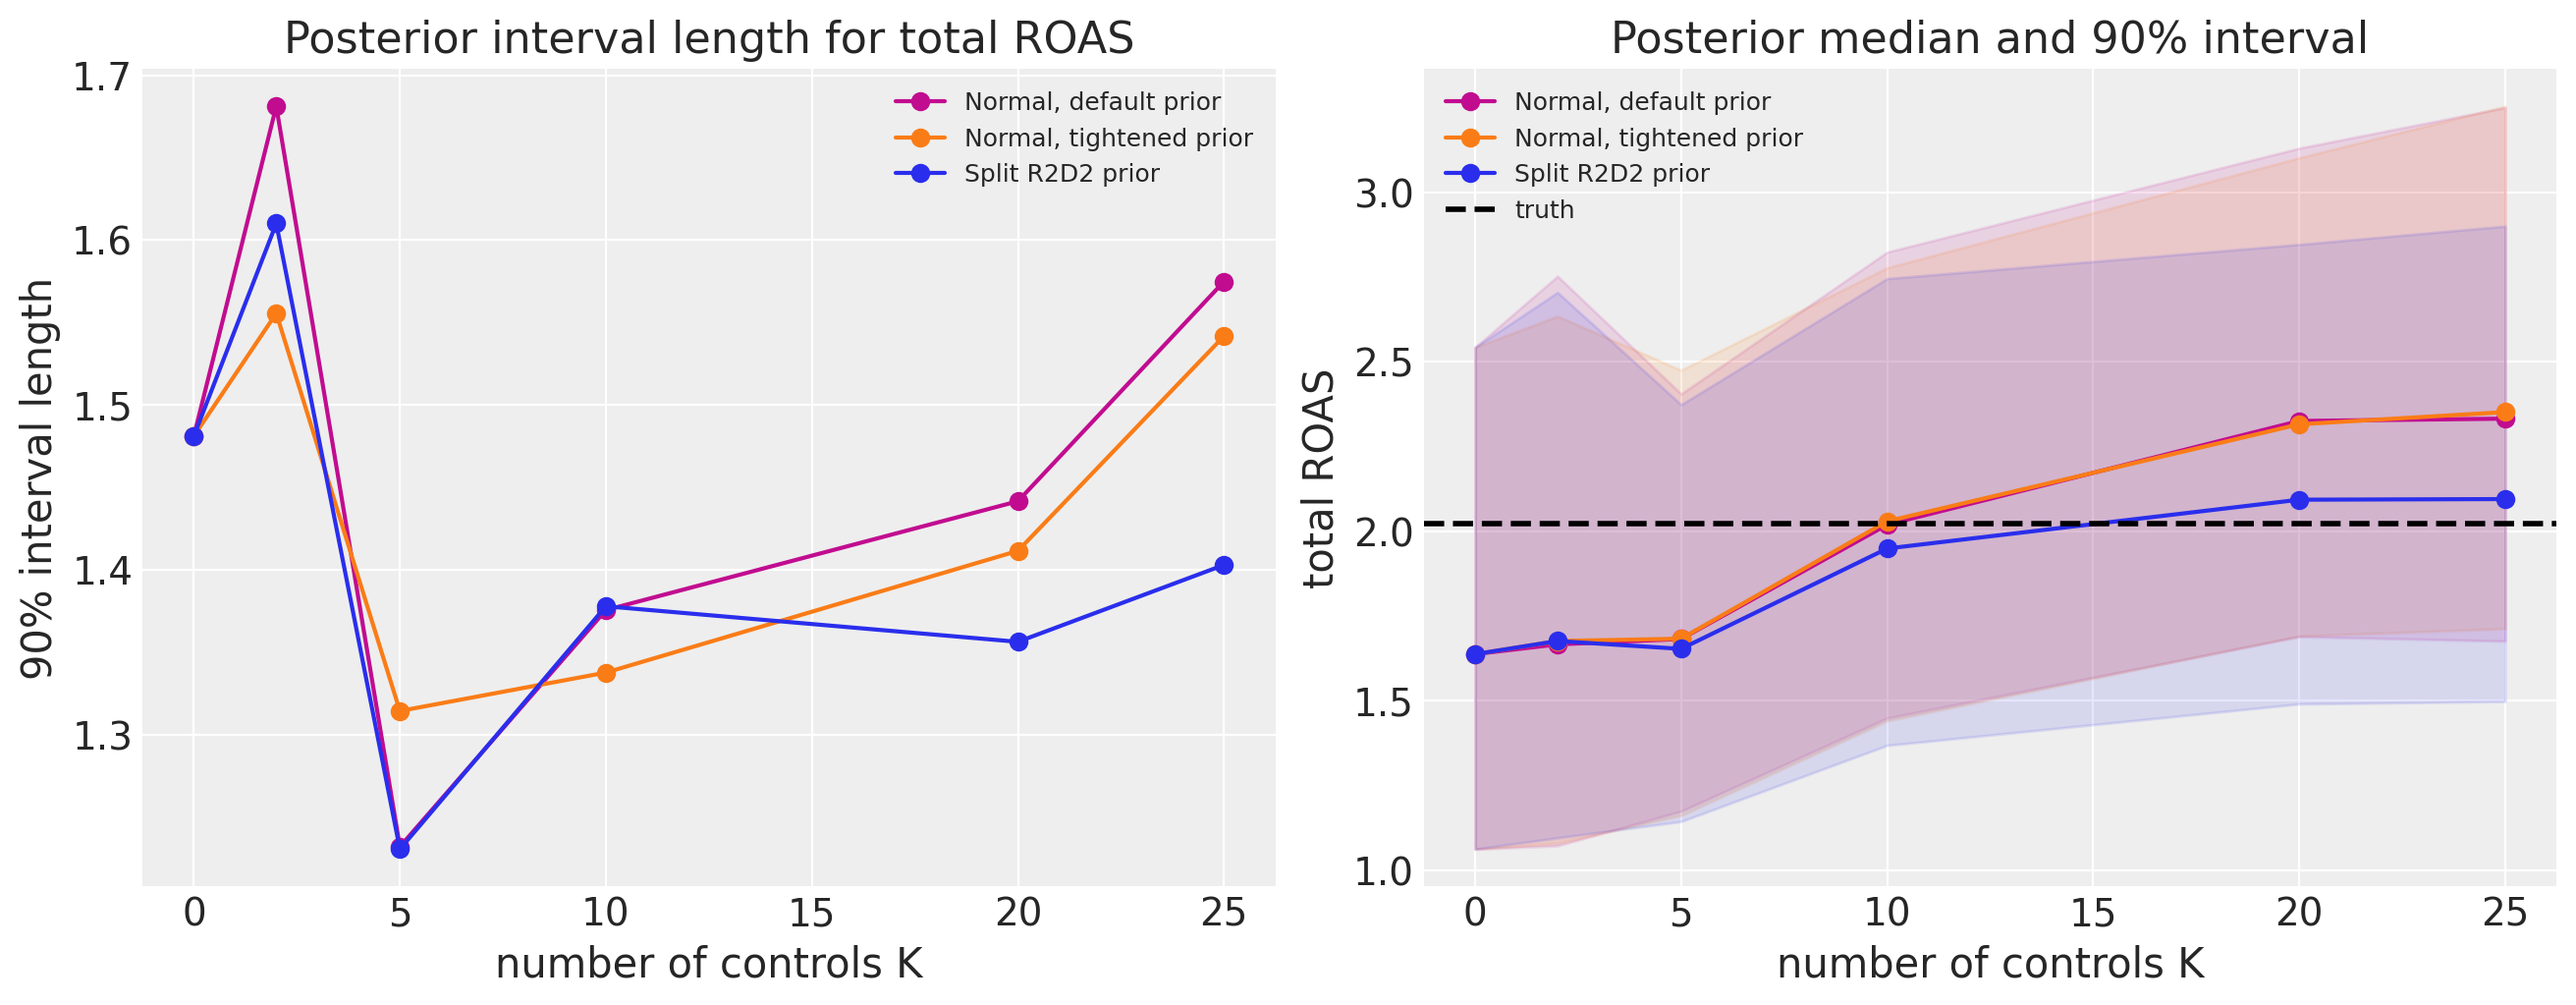

In [24]:
fig, axes = plt.subplots(ncols=2, figsize=(13, 5), sharex=True, layout="constrained")

for prior_name, color in PRIOR_COLORS.items():
    subset = by_prior(roas_table, prior_name)
    axes[0].plot(
        subset["K"],
        subset["interval_length"],
        marker="o",
        color=color,
        label=f"{prior_name} prior",
    )
    axes[1].plot(
        subset["K"],
        subset["median"],
        marker="o",
        color=color,
        label=f"{prior_name} prior",
    )
    axes[1].fill_between(
        subset["K"], subset["q05"], subset["q95"], color=color, alpha=0.12
    )

axes[0].set(
    xlabel="number of controls K",
    ylabel="90% interval length",
    title="Posterior interval length for total ROAS",
)
axes[0].legend(fontsize=9)

axes[1].axhline(
    truth["total_roas"], color="black", linestyle="--", linewidth=2, label="truth"
)
axes[1].set(
    xlabel="number of controls K",
    ylabel="total ROAS",
    title="Posterior median and 90% interval",
)
axes[1].legend(fontsize=9)

plt.show()

### Supporting view: is the variance going to the right place?

Total ROAS is a summary; it helps to see how each fit splits the target's variation between media, controls and residual, and to compare that against the truth. Because the target is max-scaled to a maximum of 1, the model's internal scale is exactly 1, so posterior and true quantities are directly comparable.

In [25]:
fits[["K", "prior", "media_share", "control_share", "posterior_r2"]].round(4)

,K,prior,media_share,control_share,posterior_r2
0,0,"Normal, default",0.2077,0.0000,0.2077
1,2,"Normal, default",0.2028,0.1455,0.3483
2,2,"Normal, tightened",0.2011,0.1434,0.3445
3,2,Split R2D2,0.2038,0.1402,0.3440
4,5,"Normal, default",0.2019,0.3559,0.5577
5,5,"Normal, tightened",0.2022,0.3540,0.5562
6,5,Split R2D2,0.2074,0.3349,0.5423
7,10,"Normal, default",0.2073,0.4958,0.7031
8,10,"Normal, tightened",0.2080,0.4929,0.7009
9,10,Split R2D2,0.2122,0.4658,0.6780


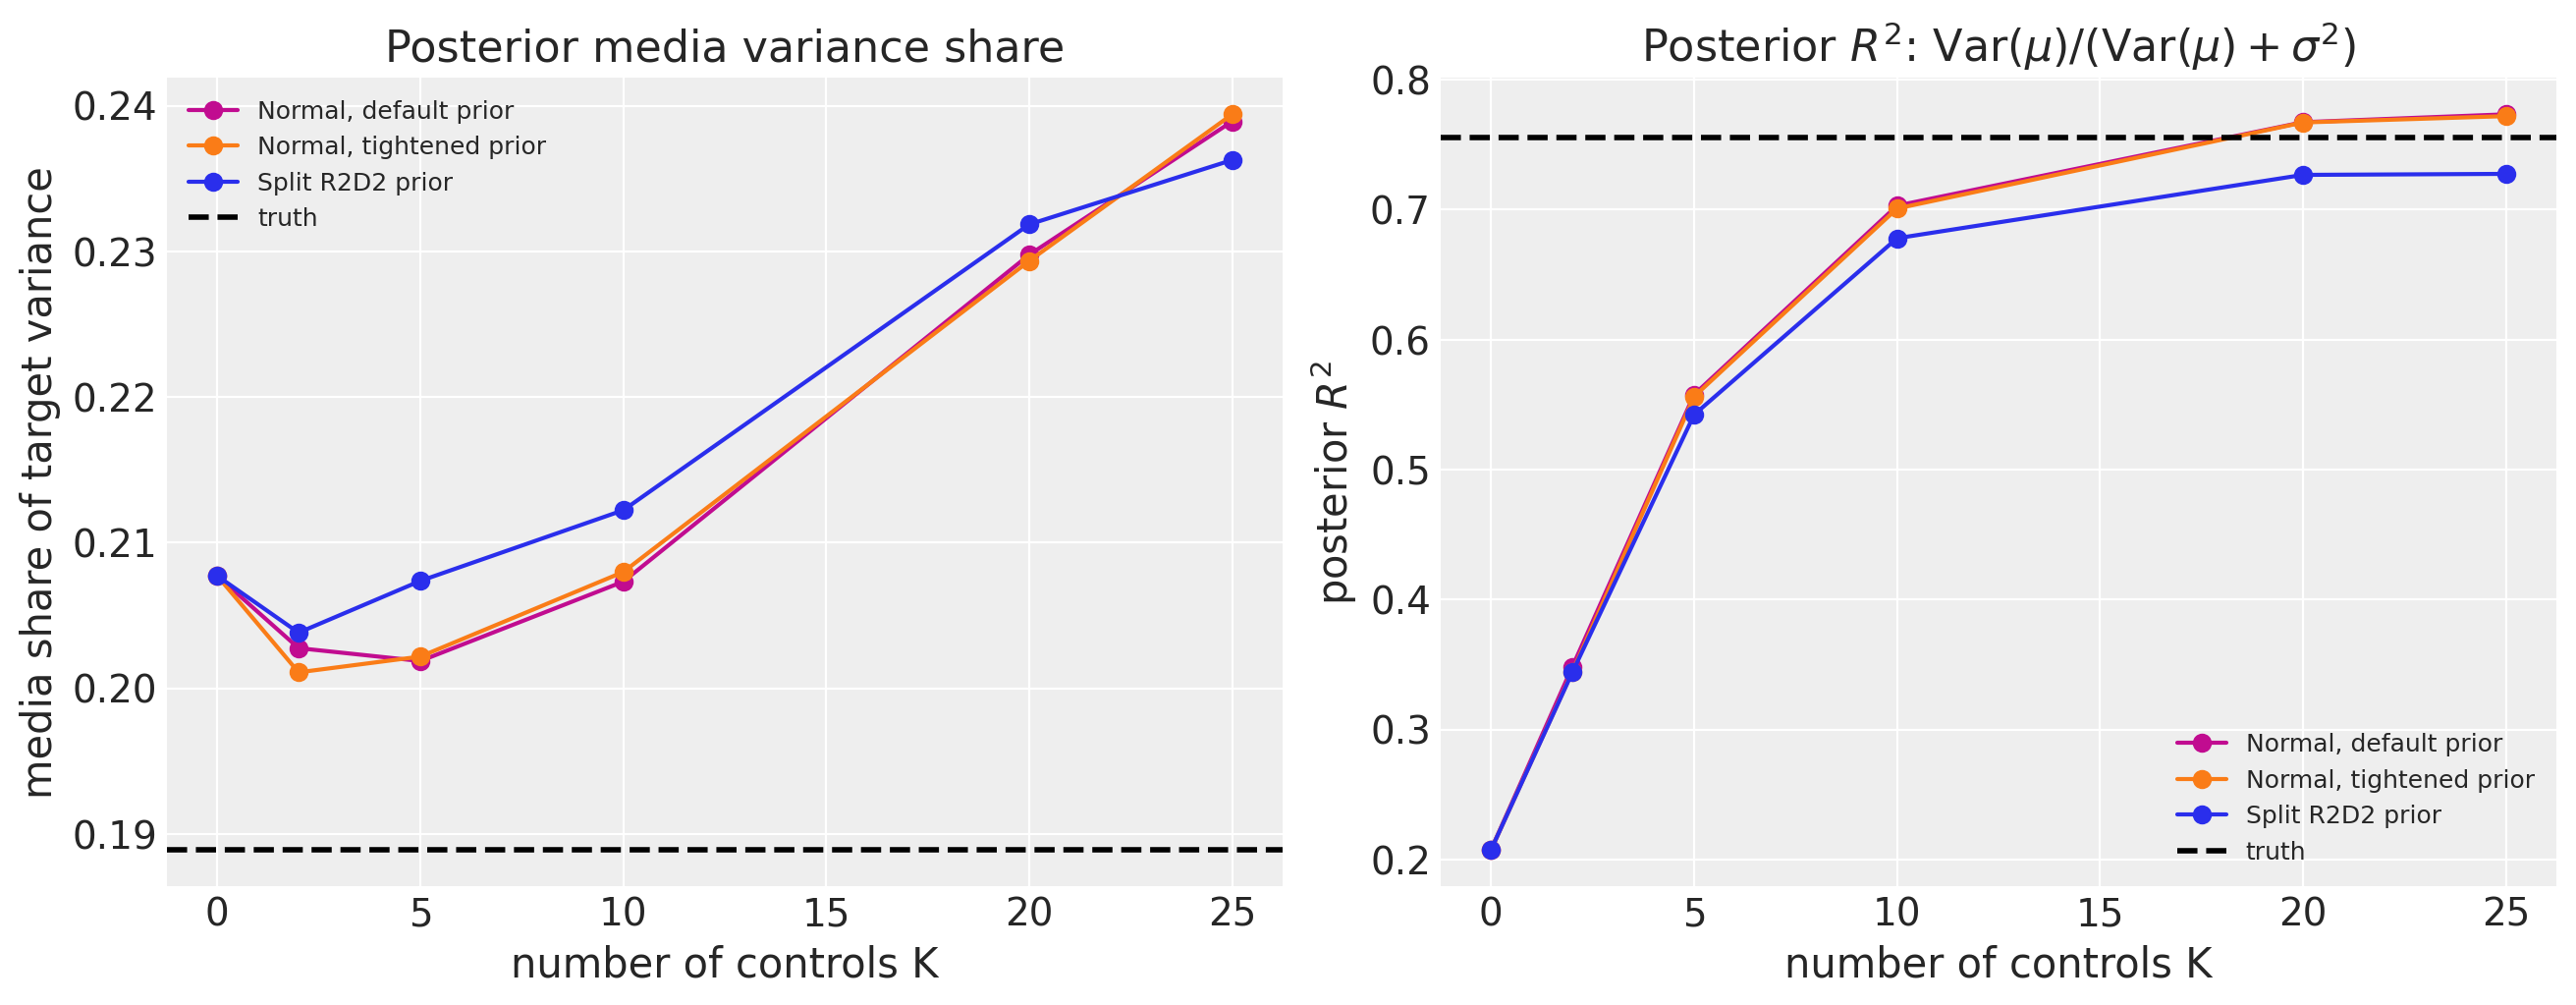

In [26]:
true_media_var_share = truth["r2"] * truth["delta_media"]

fig, axes = plt.subplots(ncols=2, figsize=(13, 5), sharex=True, layout="constrained")

for prior_name, color in PRIOR_COLORS.items():
    subset = by_prior(fits, prior_name)
    axes[0].plot(
        subset["K"],
        subset["media_share"],
        marker="o",
        color=color,
        label=f"{prior_name} prior",
    )
    axes[1].plot(
        subset["K"],
        subset["posterior_r2"],
        marker="o",
        color=color,
        label=f"{prior_name} prior",
    )

axes[0].axhline(
    true_media_var_share,
    color="black",
    linestyle="--",
    linewidth=2,
    label="truth",
)
axes[0].set(
    xlabel="number of controls K",
    ylabel="media share of target variance",
    title="Posterior media variance share",
)
axes[0].legend(fontsize=9)

axes[1].axhline(truth["r2"], color="black", linestyle="--", linewidth=2, label="truth")
axes[1].set(
    xlabel="number of controls K",
    ylabel="posterior $R^2$",
    title=r"Posterior $R^2$: $\mathrm{Var}(\mu) / (\mathrm{Var}(\mu) + \sigma^2)$",
)
axes[1].legend(fontsize=9)

plt.show()

Both panels rise with $K$, and that is expected: the controls are real signal, so a model that includes more of them should explain more. The question is where each prior stops, and this is the one place where the Normal priors come out looking better.

In the right panel they land on a posterior $R^2$ of 0.773 and 0.772 at $K = 25$ against a true 0.756, while R2D2 stops short at 0.728. Residual scale tells the same story: 0.0574 and 0.0575 against a true 0.0572, where R2D2 gives 0.0585. R2D2 is mildly *pessimistic* about the fit, by roughly as much as the Normal priors are optimistic. This is worth stating plainly rather than hiding, because it is what shrinkage costs and it is the trade the prior is making: a slightly worse description of the target's variance in exchange for a much better estimate of media's level.

The left panel is the negative result from the previous section, drawn. All three priors overshoot the true media variance share — 0.236 to 0.239 against 0.189 — and they do it together. Nothing in this figure would tell you which of the three fits is reporting a ROAS that is 17% too high.

### Diagnostics

Sampling quality per fit. This matters for interpretation: if a fit that produces a badly placed ROAS posterior also shows no sampling trouble, then nothing would have warned a practitioner that something was wrong. The flag below uses the conventional $\hat{R} \le 1.01$ threshold.

In [27]:
fits.assign(
    r_hat_flag=lambda frame: np.where(frame["max_r_hat"] > 1.01, "check", ""),
).round(4)

,K,prior,divergences,max_r_hat,posterior_sigma,gamma_sd,r2_posterior,media_share,control_share,posterior_r2,media_level_share,intercept_level_share,r_hat_flag
0,0,"Normal, default",1,1.00,0.0973,NaN,NaN,0.2077,0.0000,0.2077,0.1272,0.8724,
1,2,"Normal, default",5,1.01,0.0888,0.0075,NaN,0.2028,0.1455,0.3483,0.1328,0.8671,
2,2,"Normal, tightened",4,1.00,0.0888,0.0077,NaN,0.2011,0.1434,0.3445,0.1304,0.8694,
3,2,Split R2D2,0,1.01,0.0885,0.0075,0.5736,0.2038,0.1402,0.3440,0.1316,0.8685,
4,5,"Normal, default",0,1.00,0.0738,0.0065,NaN,0.2019,0.3559,0.5577,0.1292,0.8708,
5,5,"Normal, tightened",0,1.00,0.0738,0.0066,NaN,0.2022,0.3540,0.5562,0.1299,0.8701,
6,5,Split R2D2,0,1.00,0.0739,0.0065,0.6059,0.2074,0.3349,0.5423,0.1270,0.8730,
7,10,"Normal, default",0,1.00,0.0614,0.0061,NaN,0.2073,0.4958,0.7031,0.1545,0.8456,
8,10,"Normal, tightened",0,1.00,0.0615,0.0060,NaN,0.2080,0.4929,0.7009,0.1547,0.8453,
9,10,Split R2D2,0,1.00,0.0620,0.0061,0.6462,0.2122,0.4658,0.6780,0.1492,0.8507,


### Repetition study

A single dataset cannot separate a real effect from one draw's luck, and the paper's own effect is modest — Table 4 reports RMSE 0.30 against 0.27 and coverage 0.87 against 0.92 over many replications. The function below is the Table 4 analogue: repeat the whole pipeline over `n_reps` datasets and report 90% interval length, coverage and RMSE of total ROAS per $K$ and prior.

It defaults to `n_reps=1`, which reuses the dataset above so the notebook stays fast; raising `n_reps` is the only change needed to turn this into a proper Monte Carlo study. With `n_reps=1`, "coverage" is a single indicator per cell rather than a rate, and RMSE is the absolute error of one posterior mean — read the table as bookkeeping, and the figures above as the evidence.

In [28]:
def run_experiment(n_reps: int = 1, base_seed: int = SEED) -> pd.DataFrame:
    """Repeat simulate + fit over `n_reps` datasets."""
    records = []
    for rep in range(n_reps):
        seed = base_seed + rep
        if rep == 0:
            rep_data, rep_truth = data, truth
        else:
            rep_data, rep_truth = simulate(seed)

        for k in K_GRID:
            for prior_name in [PRIOR_NAMES[0]] if k == 0 else PRIOR_NAMES:
                if rep == 0:
                    draws = roas_draws[k, prior_name]
                else:
                    draws, _ = fit_for_k(rep_data, k, prior_name, seed=seed)

                q05, q95 = np.quantile(draws, [0.05, 0.95])
                records.append(
                    {
                        "rep": rep,
                        "K": k,
                        "prior": prior_name,
                        "interval_length": q95 - q05,
                        "covers": bool(q05 <= rep_truth["total_roas"] <= q95),
                        "squared_error": (draws.mean() - rep_truth["total_roas"]) ** 2,
                    }
                )
    return pd.DataFrame(records)


reps = run_experiment(n_reps=1)

reps.groupby(["K", "prior"]).agg(
    interval_length=("interval_length", "mean"),
    coverage=("covers", "mean"),
    rmse=("squared_error", lambda errors: np.sqrt(errors.mean())),
).round(4)

interval_length  coverage    rmse
K  prior                                               
0  Normal, default             1.4812       1.0  0.3260
2  Normal, default             1.6812       1.0  0.2516
   Normal, tightened           1.5556       1.0  0.2831
   Split R2D2                  1.6101       1.0  0.2678
5  Normal, default             1.2321       1.0  0.2992
   Normal, tightened           1.3144       1.0  0.2902
   Split R2D2                  1.2306       1.0  0.3284
10 Normal, default             1.3756       1.0  0.0372
   Normal, tightened           1.3377       1.0  0.0402
   Split R2D2                  1.3779       1.0  0.0331
20 Normal, default             1.4416       1.0  0.3328
   Normal, tightened           1.4115       1.0  0.3290
   Split R2D2                  1.3563       1.0  0.1014
25 Normal, default             1.5749       1.0  0.3577
   Normal, tightened           1.5417       1.0  0.3775
   Split R2D2                  1.4030       1.0  0.1122

## Conclusion

Adding a control variable to an MMM is not free, and the cost is not paid in the place you would look for it. The controls here are neutral by construction — independent of spend, incapable of confounding ROAS — and the data never change across fits. Everything we measured came from the prior on `gamma_control`.

What the experiment shows:

- **The mechanism is visible before any MCMC.** Under an independent Normal prior with a fixed `sigma`, the implied prior $R^2$ rises monotonically towards 1 as controls are added, and the share of prior variance available to media collapses. Under the library default `sigma=2` this has already happened at $K = 5$. R2D2 is flat in $K$, because the Dirichlet splits a fixed budget rather than accumulating one.
- **It reaches the reported number, at ordinary dimensions.** At $K = 25$ against $n = 156$ — $K/n$ of 0.16, nothing exotic — the absolute ROAS error is 0.358 under the library default and 0.378 under a hand-tightened Normal, against 0.112 under R2D2 and a true ROAS of 2.022. R2D2 also gives the narrowest interval at $K = 20$ and $K = 25$.
- **Scale is not the fix; dimension-awareness is.** The two Normal arms differ by a factor of 20 in coefficient scale and agree on ROAS to two decimal places. Tightening a prior you believe is too wide does not address the problem, because the problem is that the total budget grows with $K$.
- **Twenty-five good controls can be worth nothing.** The default Normal at $K = 25$ is no more accurate than the model with no controls at all (0.358 against 0.326) — the source paper's Table 4, reproduced. Under R2D2 the same controls cut the error by a factor of three. The controls were fine; the prior decided whether they helped.
- **The failure is in the level, not the variance.** All three priors agree on media's share of target variance to within 0.003 and all three overshoot the truth. They disagree on media's share of mean *sales* — 0.179, 0.180 and 0.160 against a true 0.152 — and that is the quantity ROAS is made of.

Practical takeaways:

1. **The default `gamma_control` prior does not know how many controls you have.** `Prior("Normal", mu=0, sigma=2, dims="control")` is a strong statement about total explained variance once $K$ is more than a handful, and it gets stronger every time you add a column.
2. **Check the implied prior $R^2$.** It costs one `sample_prior_predictive` call and no sampling, and it is the fastest way to find out whether your control prior is quietly asserting a near-perfect fit.
3. **Ask what your control block could mimic.** Regress your media contribution — fitted, if you have no truth — on the control block and look at the $R^2$. It is a two-line diagnostic, it tells you how much capacity the block has to explain media away, and it is far more informative than the pairwise correlations most people check.
4. **Standardise your controls.** All three priors are stated on the scale of the coefficients, and `MMM` does not scale controls for you. A shared variance budget is only meaningful once the columns are comparable.
5. **A split prior is enough.** Putting R2D2 on the controls alone leaves every media prior untouched, so the media parameterisation you have tuned stays exactly as it was. The joint version, which shrinks media too, is a different and — per the paper — considerably worse idea.
6. **Diagnostics will not save you.** Every fit at $K \ge 5$ reports zero divergences and no $\hat{R}$ above 1.01, including the ones whose ROAS is 17% too high. Nothing in the sampler output distinguishes the fit you should trust from the two you should not.

### What this notebook does not do

- **A proper repetition study.** `run_experiment` defaults to one replication, so every number above is a single realisation. The ordering is stable across $K$ and survives a change of media priors, but the *size* of the effect needs `n_reps` in the tens and a compute budget to match. This is the most important gap.
- **Confounded controls.** Spend here is generated without reference to any control, including the seasonal one. Real marketers spend into high season, which makes seasonality a genuine confounder and changes the calculus entirely — omitting it then biases ROAS for reasons that have nothing to do with prior geometry.
- **The joint R2D2 prior**, spanning media and control coefficients together, which the paper shows is badly biased.
- **Multiple geos.** The class used here is the dims-based `MMM` either way, so adding `dims=("geo",)` is mostly a matter of widening the prior dims and the spend generator.
- **Promoting `R2D2Prior` and `SharedScale` into `pymc_marketing`** with tests and serialisation registration. Both are defined locally here; upstreaming `R2D2Prior` alongside `LaplacePrior` and `LogNormalPrior` would be a natural follow-up.

## References

- [*To select or not to select: that is the question*](https://arxiv.org/abs/2606.22850) — the source of the experiment this notebook translates. Experiment 4, Section 5.4, Figures 4 and 9, Table 4.
- Zhang, Y. D., Naughton, B. P., Bondell, H. D., & Reich, B. J. (2022). [Bayesian Regression Using a Prior on the Model Fit: The R2-D2 Shrinkage Prior](https://doi.org/10.1080/01621459.2020.1825449). *Journal of the American Statistical Association*.
- Cinelli, C., Forney, A., & Pearl, J. (2024). [A Crash Course in Good and Bad Controls](https://doi.org/10.1177/00491241221099552). *Sociological Methods & Research*.
- Jin, Y., Wang, Y., Sun, Y., Chan, D., & Koehler, J. (2017). [Bayesian Methods for Media Mix Modeling with Carryover and Shape Effects](https://research.google/pubs/pub46001/).

In [29]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor,pymc

Last updated: Tue, 04 Aug 2026

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.15.0

pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7
pymc          : 6.0.1

arviz         : 1.2.0
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc          : 6.0.1
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

